In [ ]:
import os
import pandas as pd
import numpy as np

import music21
import pretty_midi
from music21 import converter, chord

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/train_features.csv")

pitch_mapping = {
    "pitch_class_0": "C",
    "pitch_class_1": "C#/Db",
    "pitch_class_2": "D",
    "pitch_class_3": "D#/Eb",
    "pitch_class_4": "E",
    "pitch_class_5": "F",
    "pitch_class_6": "F#/Gb",
    "pitch_class_7": "G",
    "pitch_class_8": "G#/Ab",
    "pitch_class_9": "A",
    "pitch_class_10": "A#/Bb",
    "pitch_class_11": "B"
}

df.rename(columns=pitch_mapping, inplace=True)

df.head()

,composer,filename,tempo,num_notes,num_chords,avg_pitch,pitch_range,avg_duration,avg_velocity,note_density,...,B,register_center,range_normalized,notes_per_chord,chord_density,velocity_variation,tempo_note_ratio,chromatic_ratio,pitch_entropy,pitch_class_variance
0,bach,bach342.mid,248.235754,6479,5539,63.972681,51,0.386120,127.0,7.081842,...,0.148017,63.972681,0.797215,1.169495,0.854784,0.509558,0.038308,0.375829,2.224046,0.003079
1,bach,bach343.mid,233.938023,4072,3149,67.986739,45,0.332399,127.0,9.136393,...,0.102898,67.986739,0.661894,1.292698,0.773140,0.540568,0.057436,0.282907,2.102536,0.004441
2,bach,bach345.mid,266.035285,624,632,64.177885,46,0.395310,127.0,6.994454,...,0.166667,64.177885,0.716758,0.985782,1.011200,0.475593,0.425656,0.185897,2.188287,0.003382
3,bach,bach346.mid,230.553293,539,629,64.491651,46,0.529791,127.0,5.230563,...,0.025974,64.491651,0.713271,0.855556,1.164815,0.548470,0.426951,0.294990,2.275108,0.002642
4,bach,bach347.mid,175.318569,891,802,62.205387,46,0.195700,127.0,9.694524,...,0.142536,62.205387,0.739486,1.109589,0.899103,0.720287,0.196545,0.443322,2.166209,0.003422


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(369, 31)
<class 'pandas.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   composer              369 non-null    str    
 1   filename              369 non-null    str    
 2   tempo                 369 non-null    float64
 3   num_notes             369 non-null    int64  
 4   num_chords            369 non-null    int64  
 5   avg_pitch             369 non-null    float64
 6   pitch_range           369 non-null    int64  
 7   avg_duration          369 non-null    float64
 8   avg_velocity          369 non-null    float64
 9   note_density          369 non-null    float64
 10  C                     369 non-null    float64
 11  C#/Db                 369 non-null    float64
 12  D                     369 non-null    float64
 13  D#/Eb                 369 non-null    float64
 14  E                     369 non-null    float64
 15  F                     36

composer
bach           42
byrd           42
hummel         42
bartok         41
chopin         41
handel         41
mendelssohn    41
mozart         41
schumann       38
Name: count, dtype: int64


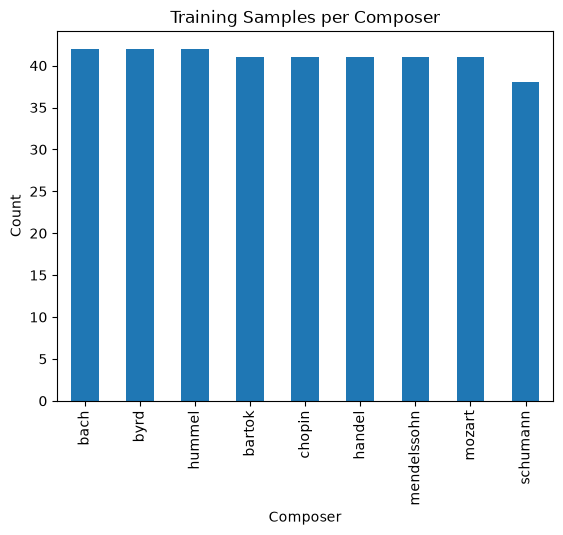

In [4]:
composer_counts = df["composer"].value_counts()

print(composer_counts)

composer_counts.plot(kind="bar")

plt.title("Training Samples per Composer")
plt.xlabel("Composer")
plt.ylabel("Count")

plt.show()

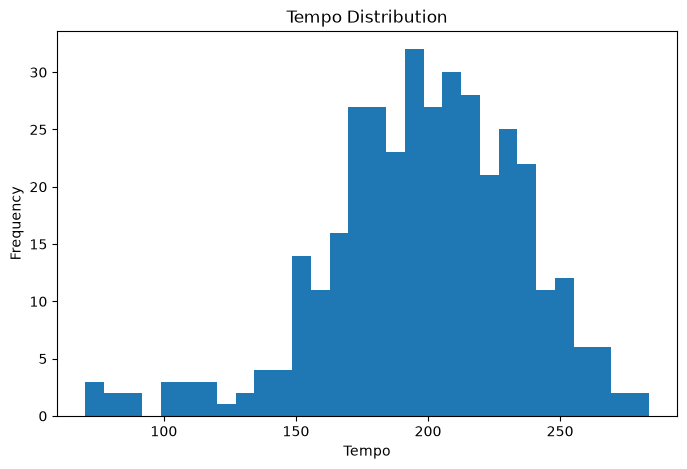

In [5]:
plt.figure(figsize=(8,5))

plt.hist(df["tempo"], bins=30)

plt.title("Tempo Distribution")
plt.xlabel("Tempo")
plt.ylabel("Frequency")

plt.show()

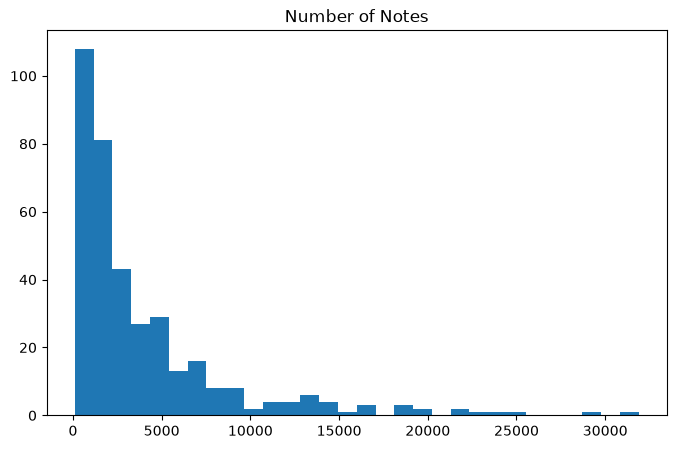

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["num_notes"], bins=30)

plt.title("Number of Notes")

plt.show()

<Figure size 1200x600 with 0 Axes>

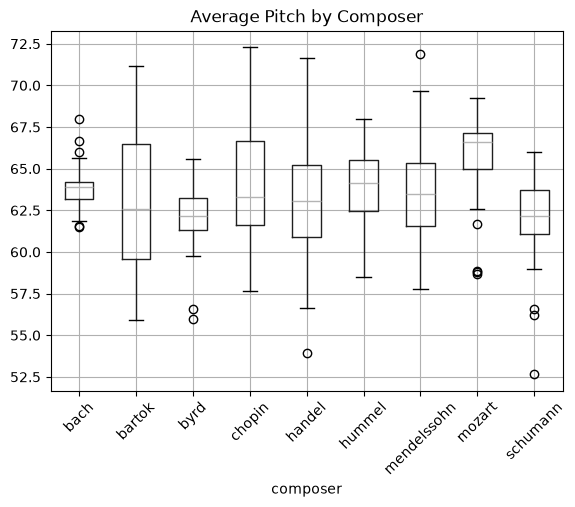

In [7]:
plt.figure(figsize=(12,6))

df.boxplot(column="avg_pitch", by="composer", rot=45)

plt.title("Average Pitch by Composer")
plt.suptitle("")

plt.show()

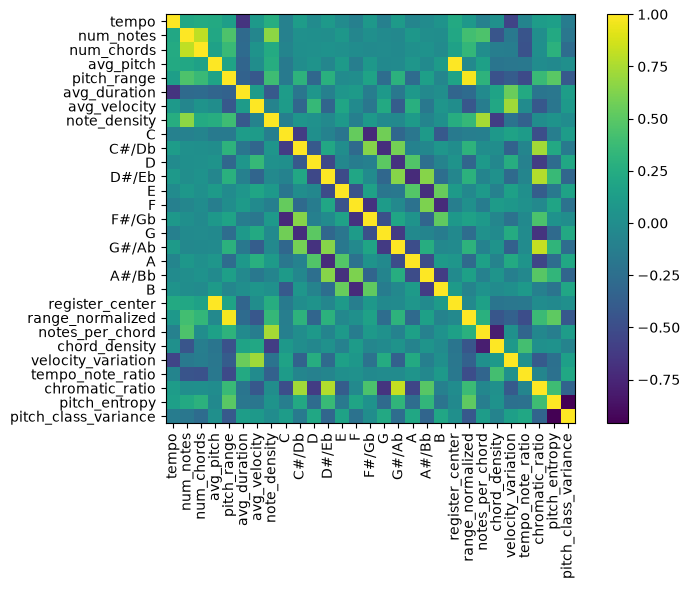

In [8]:
numeric_df = df.drop(columns=["composer", "filename"])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.tight_layout()
plt.show()

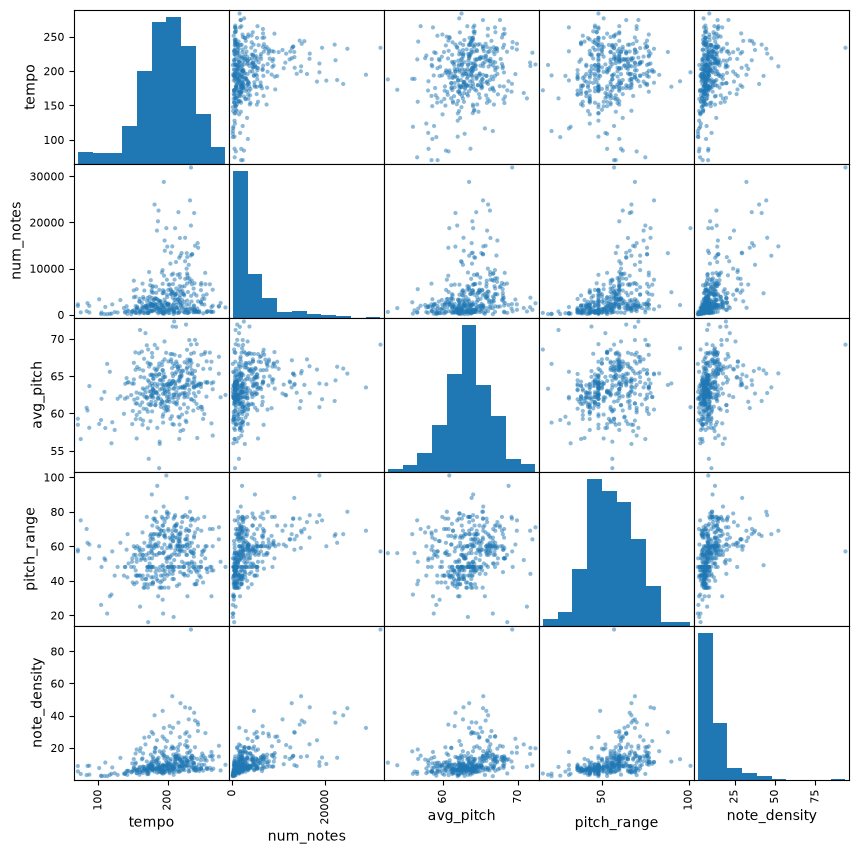

In [9]:
cols = [
    "tempo",
    "num_notes",
    "avg_pitch",
    "pitch_range",
    "note_density"
]

pd.plotting.scatter_matrix(
    df[cols],
    figsize=(10,10),
    diagonal="hist"
)

plt.show()

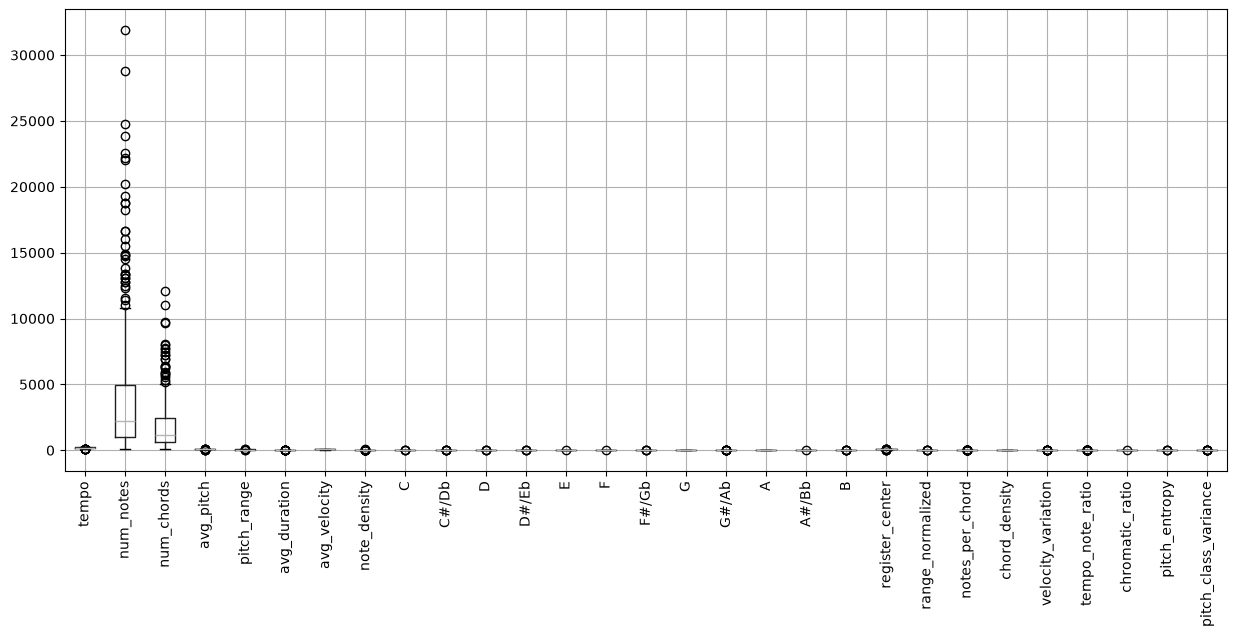

In [10]:
numeric_df.boxplot(figsize=(15,6), rot=90)

plt.show()

In [11]:
summary = df.groupby("composer").mean(numeric_only=True)

print(summary)

                  tempo    num_notes   num_chords  avg_pitch  pitch_range  \
composer                                                                    
bach         219.959537  2087.357143  1869.880952  63.789523    46.952381   
bartok       190.406022  3039.048780   926.560976  62.995708    54.780488   
byrd         182.431964  1618.976190  1366.619048  62.124578    39.380952   
chopin       204.877103  2586.073171  1609.780488  64.045146    67.341463   
handel       175.666853  3343.560976   945.512195  62.914867    54.804878   
hummel       208.430929  5854.928571  3119.857143  63.960452    58.095238   
mendelssohn  200.877926  5750.585366  2024.243902  63.403599    64.390244   
mozart       204.648208  7133.536585  2695.463415  65.749972    58.048780   
schumann     193.756822  4704.315789  2103.157895  61.936209    58.105263   

             avg_duration  avg_velocity  note_density         C     C#/Db  \
composer                                                                   

Dataset shape: (439, 31)

Composer counts:
composer
bach           50
byrd           50
hummel         50
bartok         49
chopin         49
handel         49
mendelssohn    49
mozart         49
schumann       44
Name: count, dtype: int64

Feature summary:


,tempo,num_notes,num_chords,avg_pitch,pitch_range,avg_duration,avg_velocity,note_density,pitch_class_0,pitch_class_1,...,pitch_class_11,register_center,range_normalized,notes_per_chord,chord_density,velocity_variation,tempo_note_ratio,chromatic_ratio,pitch_entropy,pitch_class_variance
count,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,...,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000,439.000000
mean,199.050513,3899.318907,1836.879271,63.434399,55.644647,0.381786,88.790029,11.563105,0.102612,0.054087,...,0.087998,63.434399,0.877796,2.143413,0.614707,0.461380,0.164238,0.277854,2.174232,0.003910
std,36.533248,4660.916044,1845.793855,3.064848,12.987750,0.215147,26.542324,8.769256,0.062955,0.052319,...,0.060352,3.064848,0.204134,1.472517,0.273879,0.175992,0.211410,0.168993,0.151136,0.001932
min,70.272438,109.000000,62.000000,52.663793,16.000000,0.070979,35.392252,2.061826,0.000000,0.000000,...,0.000000,52.663793,0.233381,0.703187,0.064492,0.181999,0.006766,0.000000,1.589548,0.000022
25%,177.541416,977.500000,605.500000,61.656128,47.000000,0.238515,68.358666,6.616041,0.058242,0.014908,...,0.038232,61.656128,0.739834,1.204372,0.405109,0.328531,0.039227,0.137593,2.081837,0.002707
50%,201.142857,2198.000000,1134.000000,63.489462,56.000000,0.329288,85.336134,8.837213,0.100962,0.033595,...,0.083969,63.489462,0.878597,1.722689,0.577922,0.428357,0.087407,0.255686,2.166810,0.003897
75%,224.682469,5026.500000,2502.500000,65.343098,64.000000,0.498962,109.726549,13.416966,0.141472,0.085934,...,0.122469,65.343098,1.006830,2.463667,0.829431,0.551486,0.195738,0.401069,2.276429,0.004856
max,283.645377,31879.000000,12054.000000,72.311264,101.000000,1.591706,127.000000,93.514321,0.421717,0.311936,...,0.333333,72.311264,1.660103,15.497812,1.415254,1.306923,1.710817,0.912182,2.483315,0.014556



Missing values:


composer                0
filename                0
tempo                   0
num_notes               0
num_chords              0
avg_pitch               0
pitch_range             0
avg_duration            0
avg_velocity            0
note_density            0
pitch_class_0           0
pitch_class_1           0
pitch_class_2           0
pitch_class_3           0
pitch_class_4           0
pitch_class_5           0
pitch_class_6           0
pitch_class_7           0
pitch_class_8           0
pitch_class_9           0
pitch_class_10          0
pitch_class_11          0
register_center         0
range_normalized        0
notes_per_chord         0
chord_density           0
velocity_variation      0
tempo_note_ratio        0
chromatic_ratio         0
pitch_entropy           0
pitch_class_variance    0
dtype: int64

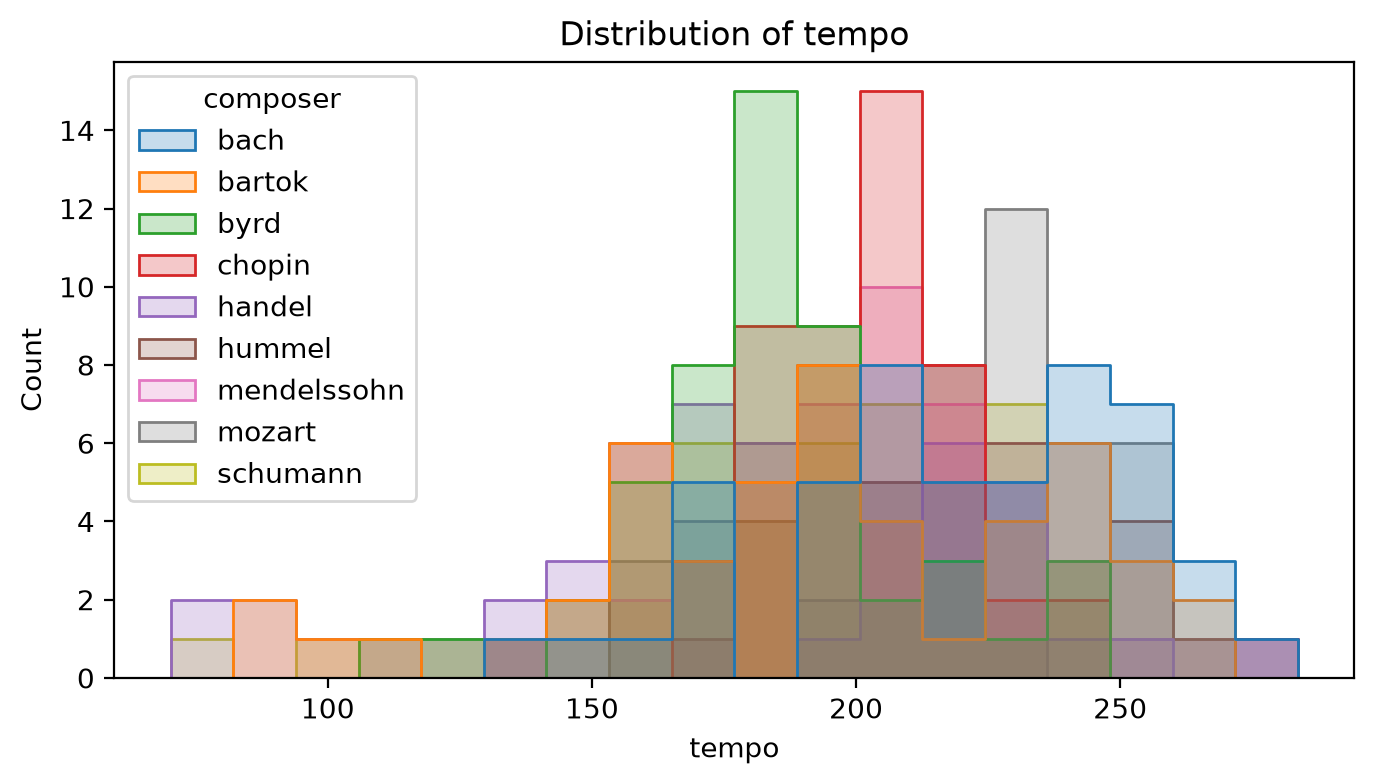

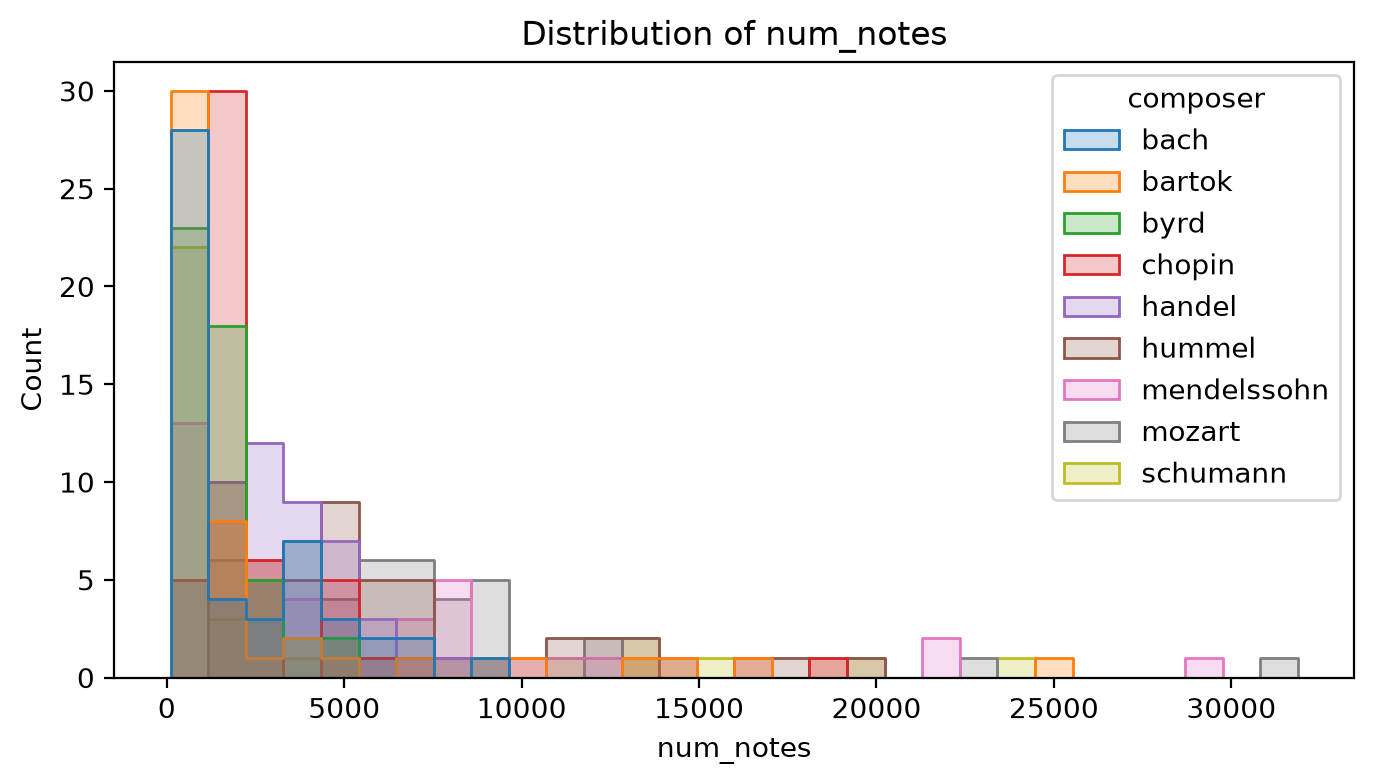

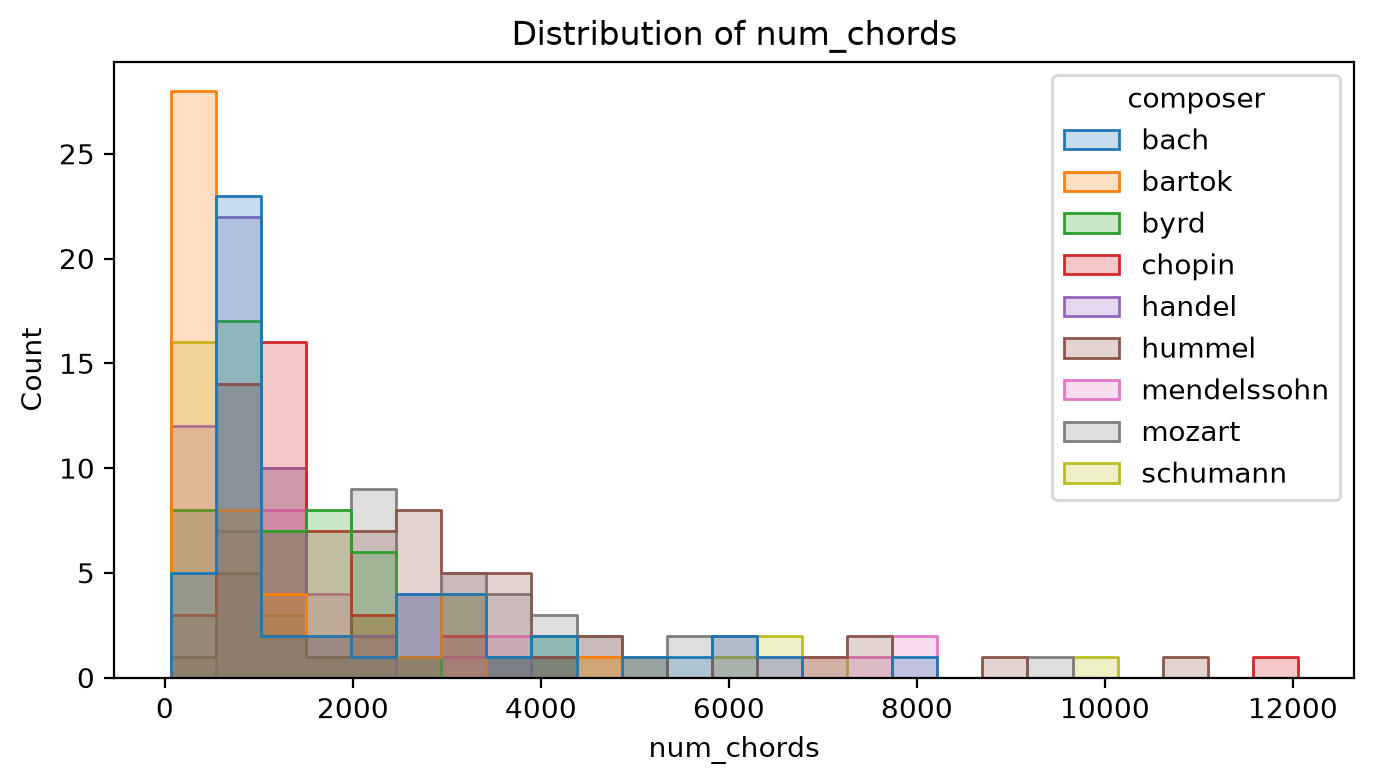

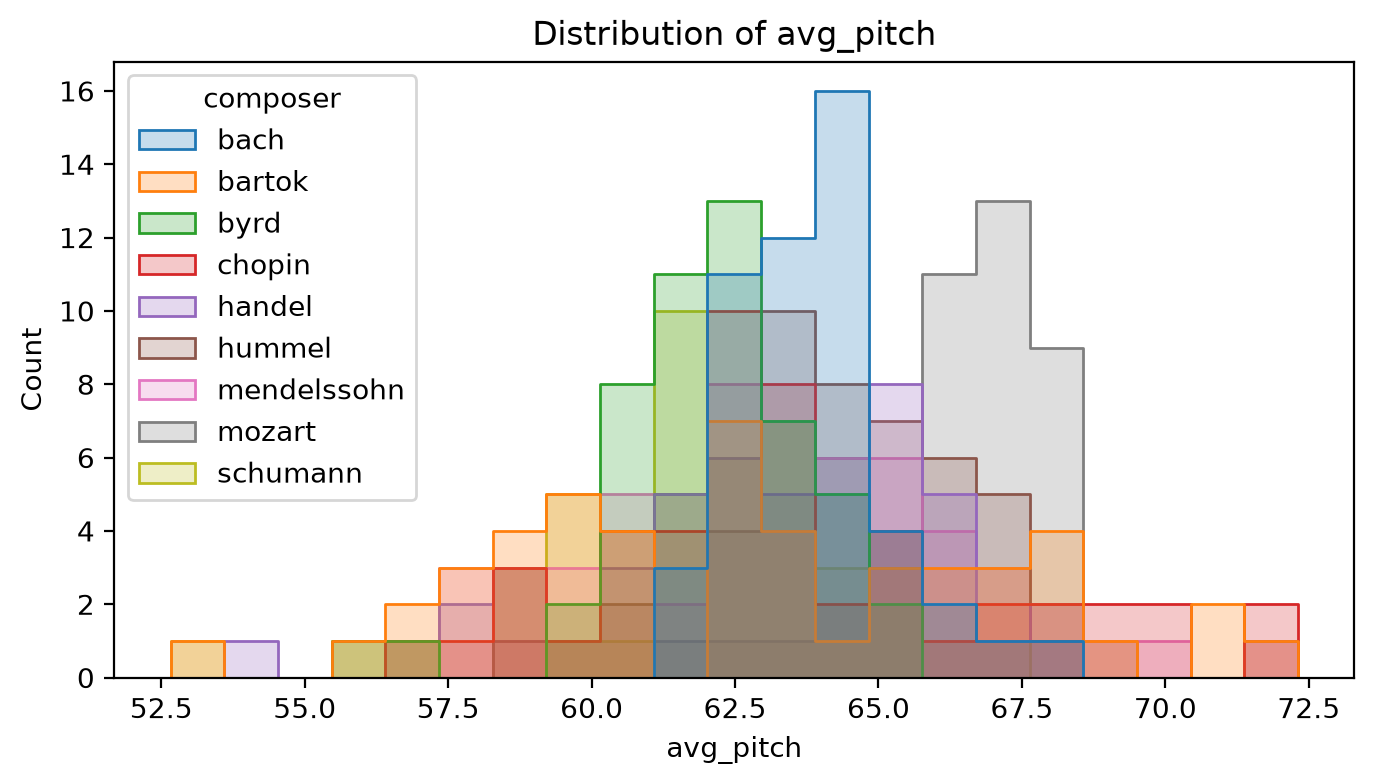

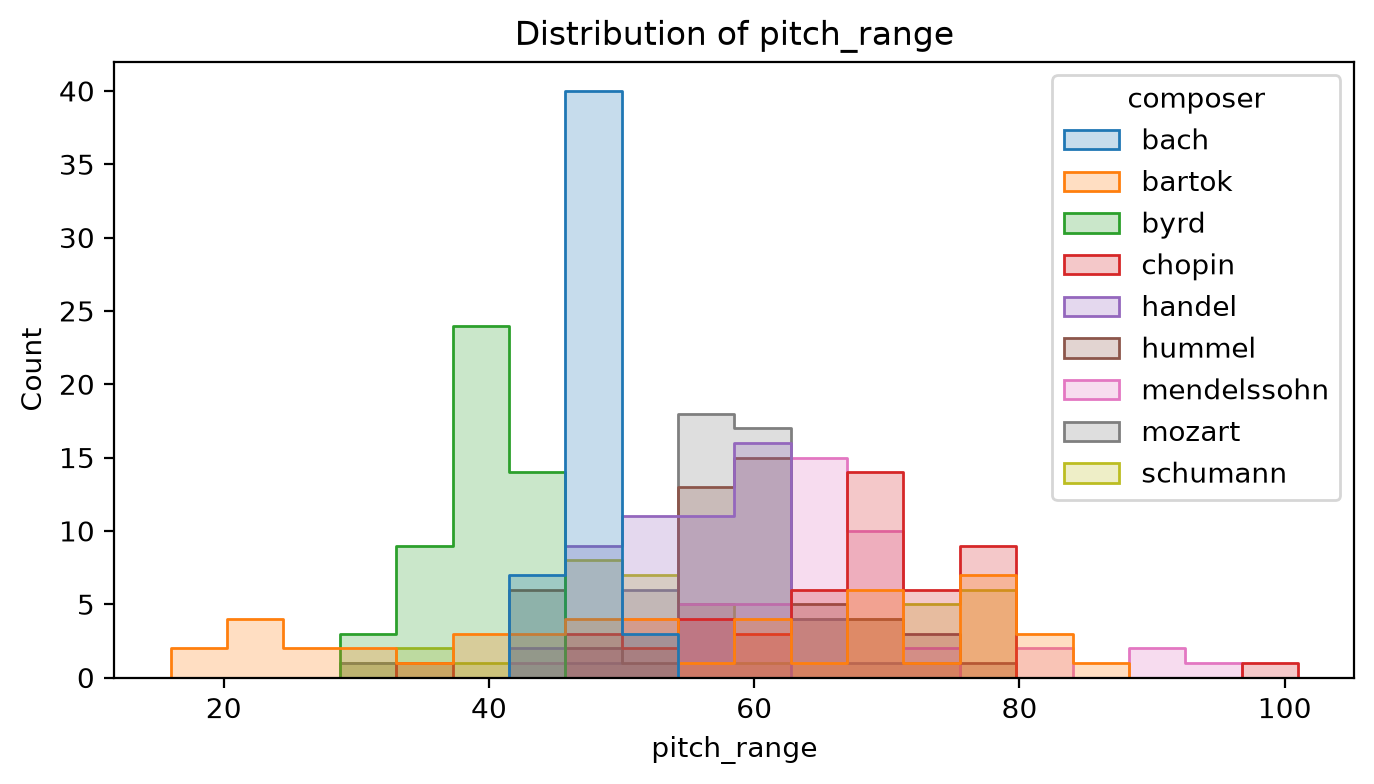

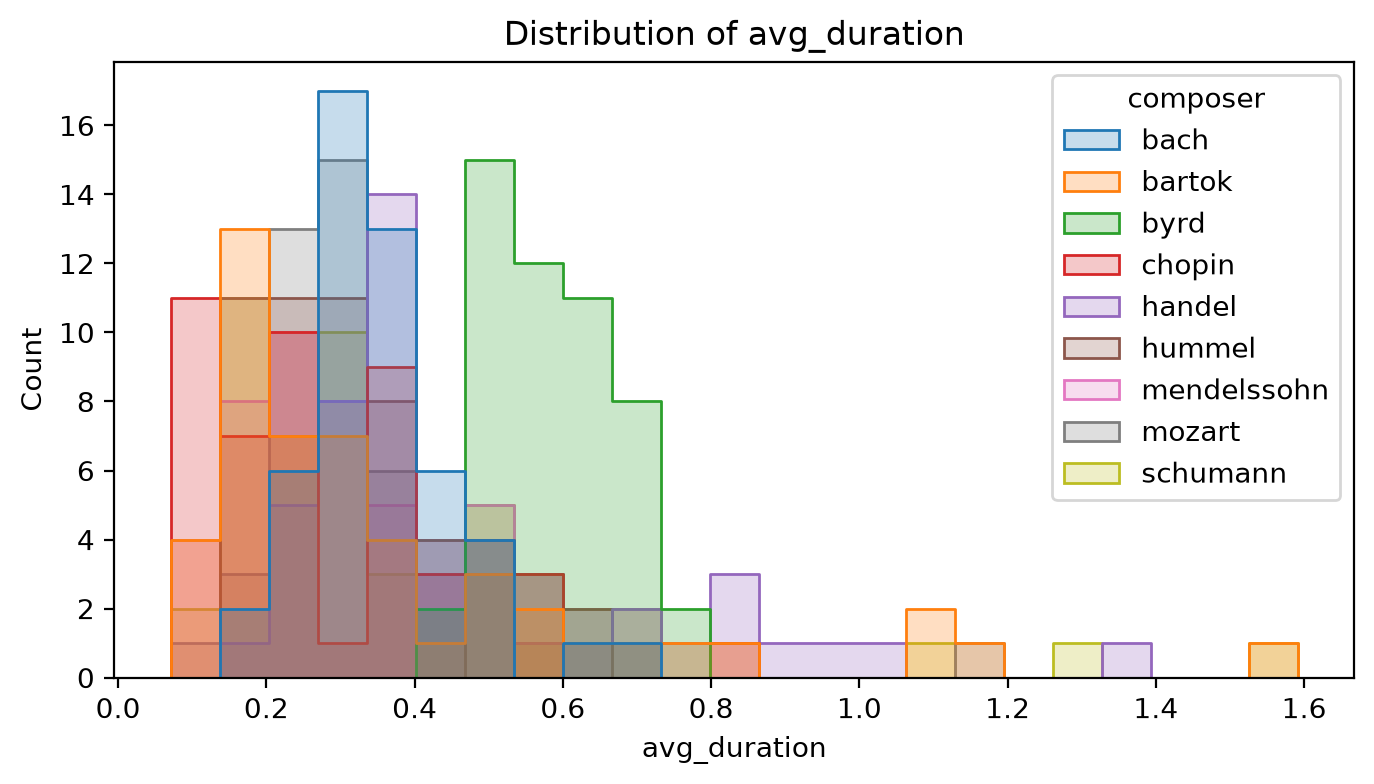

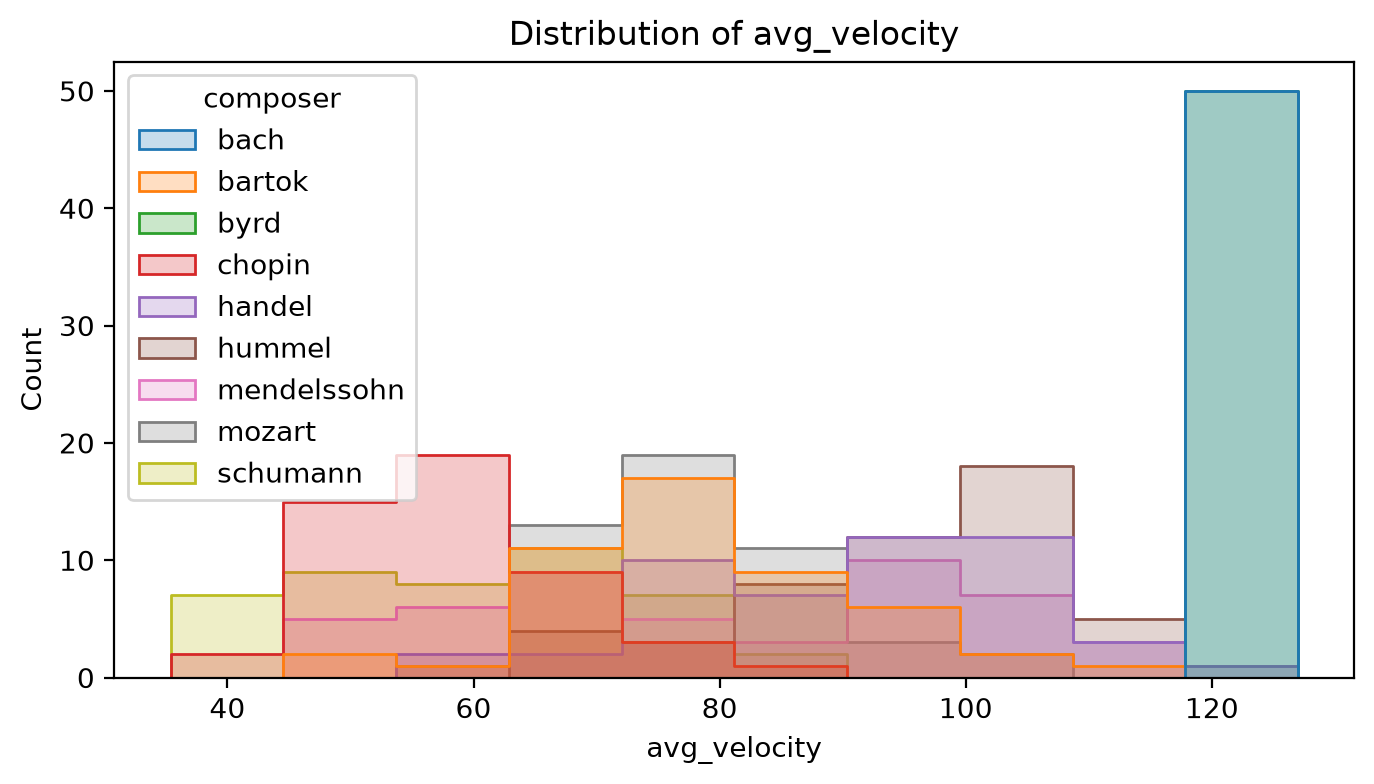

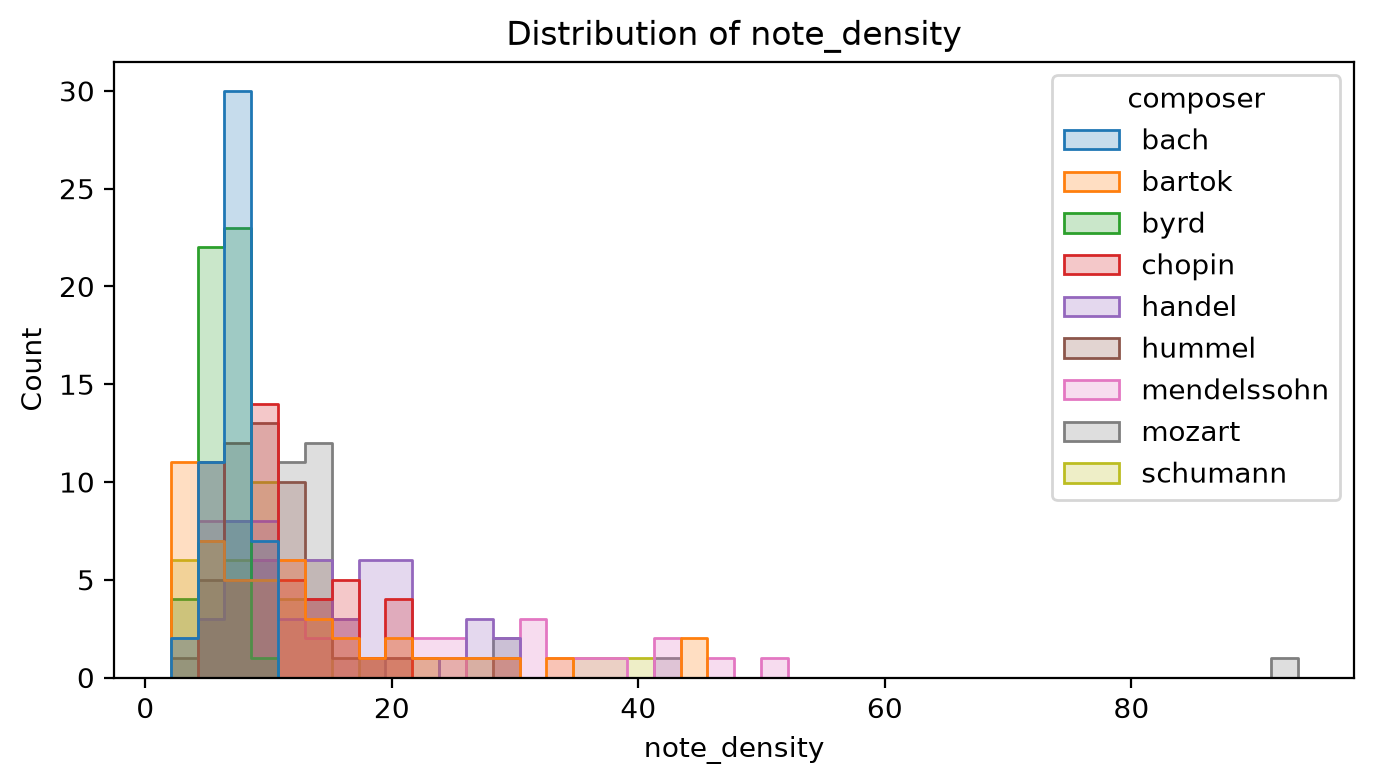

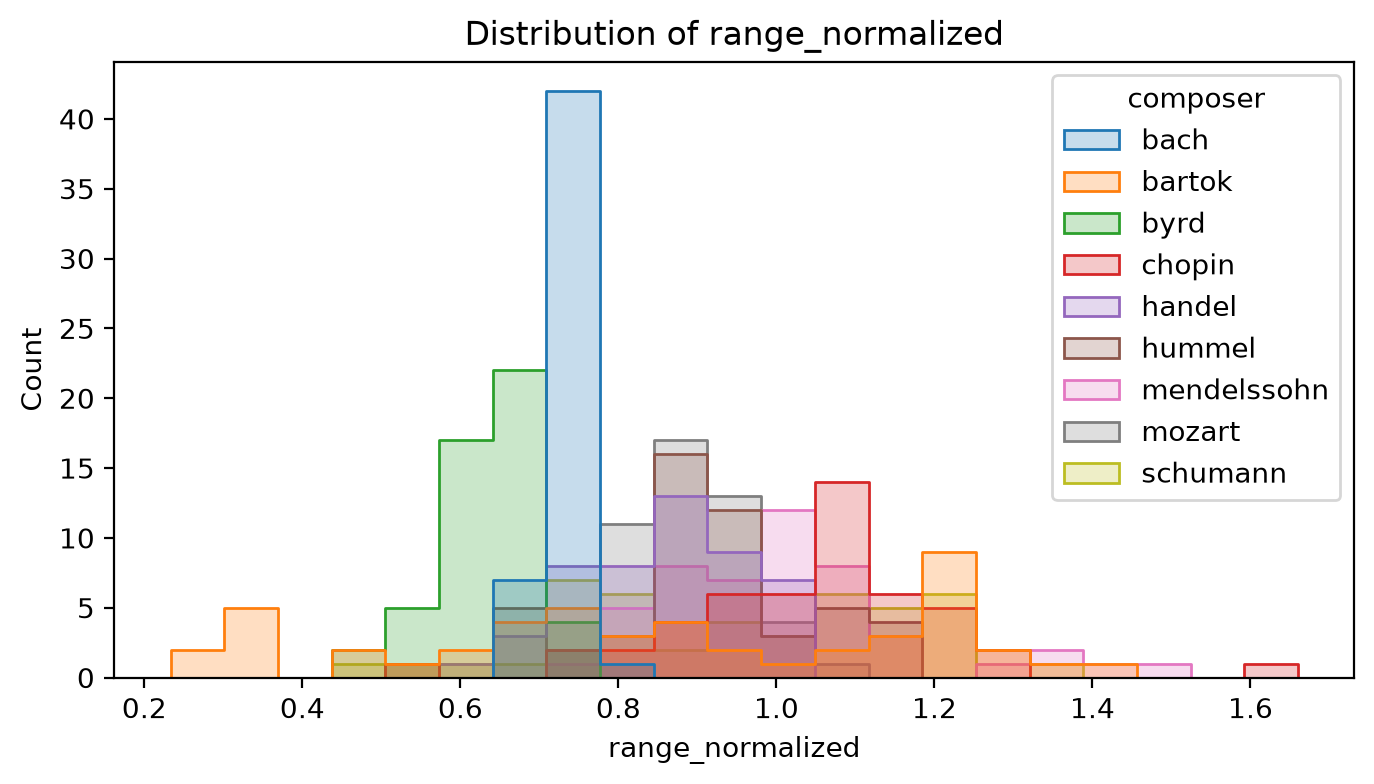

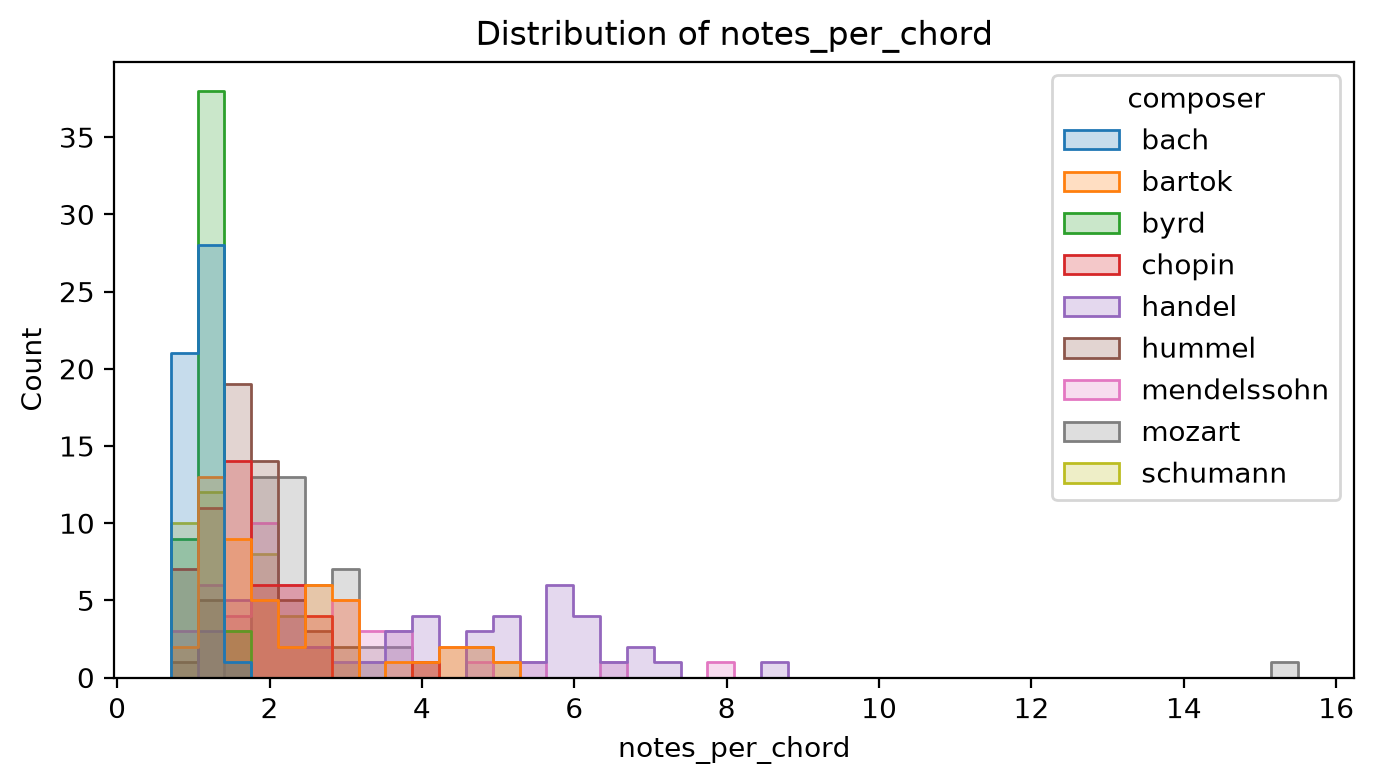

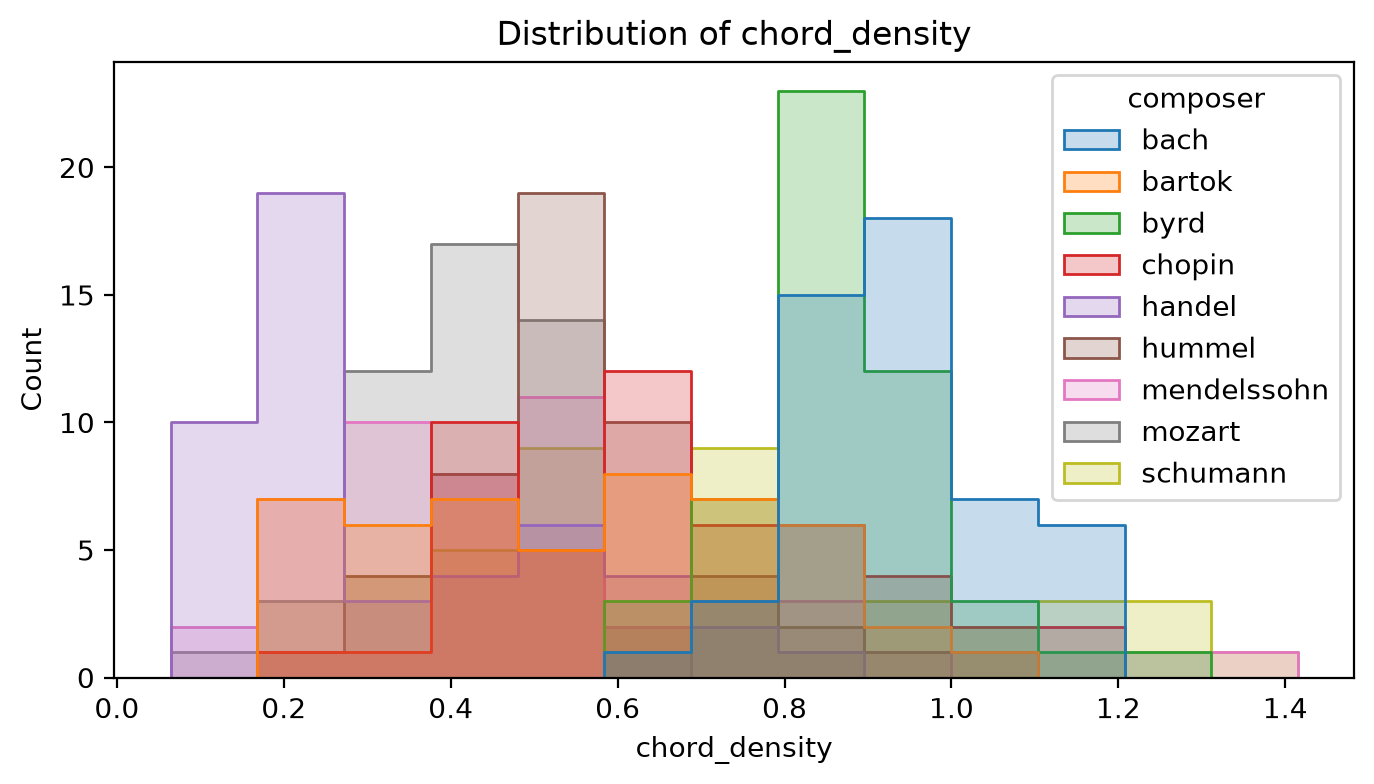

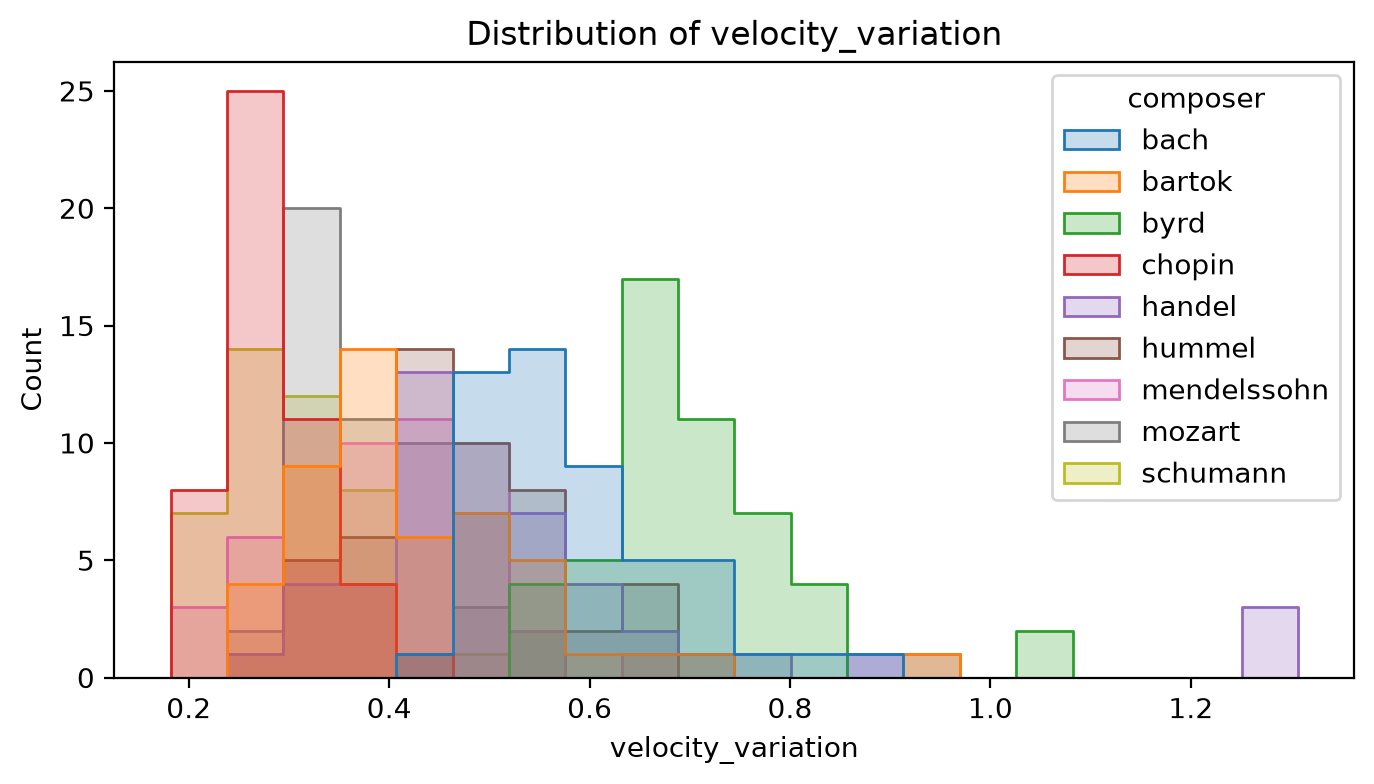

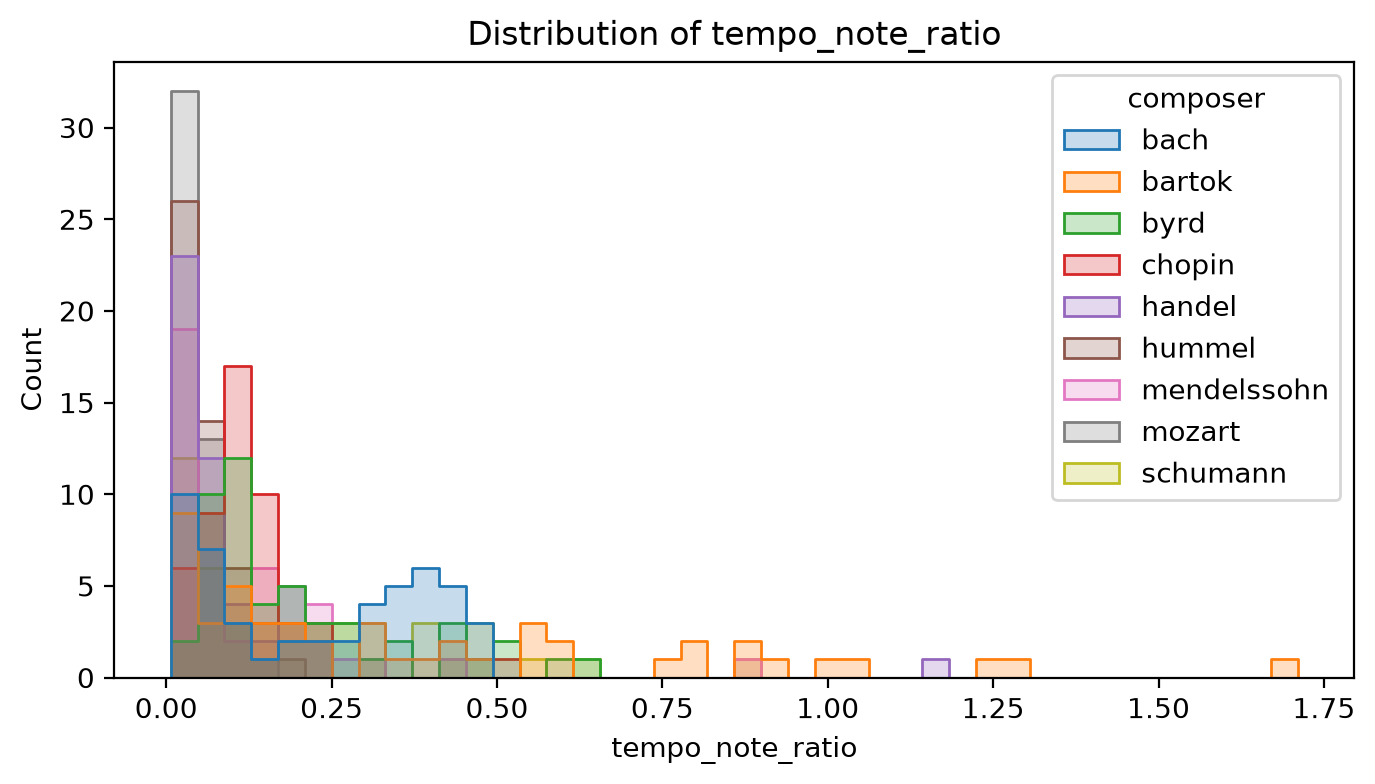

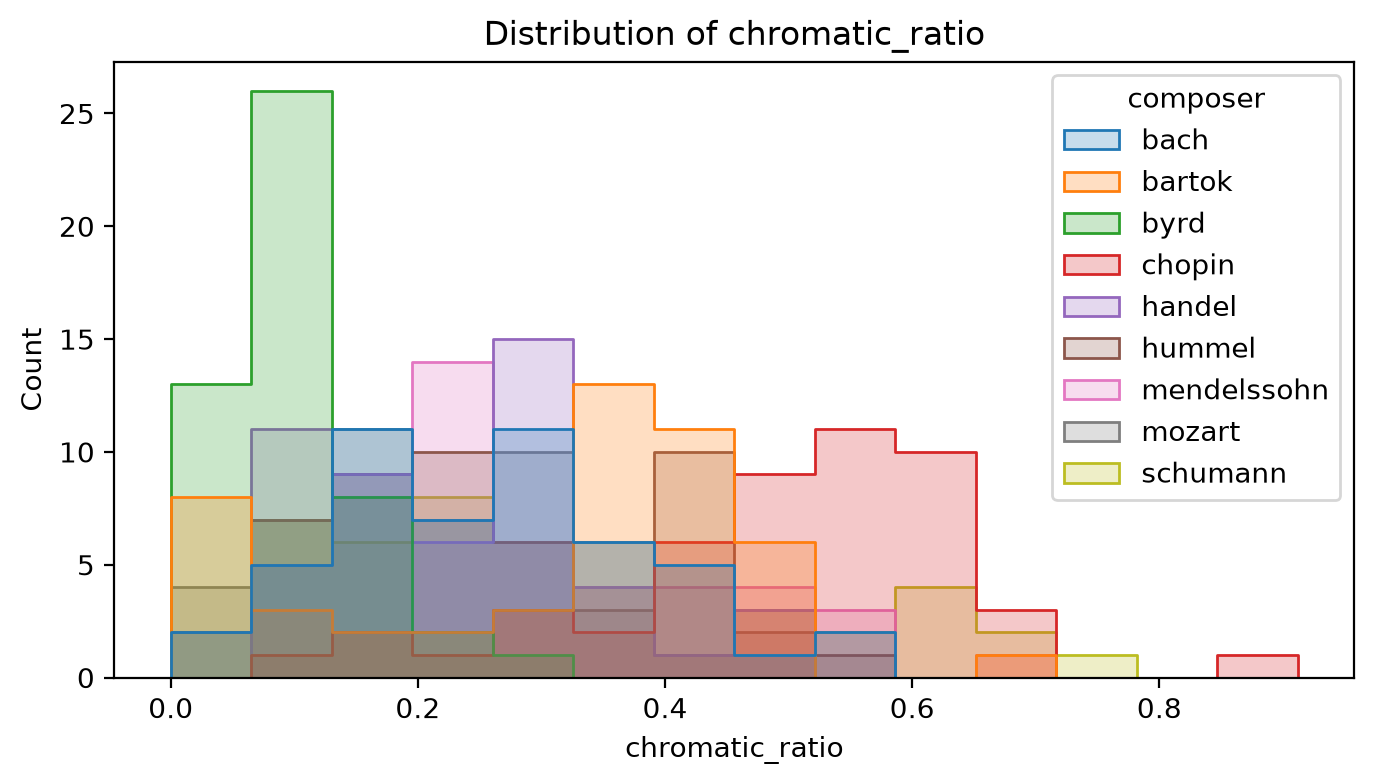

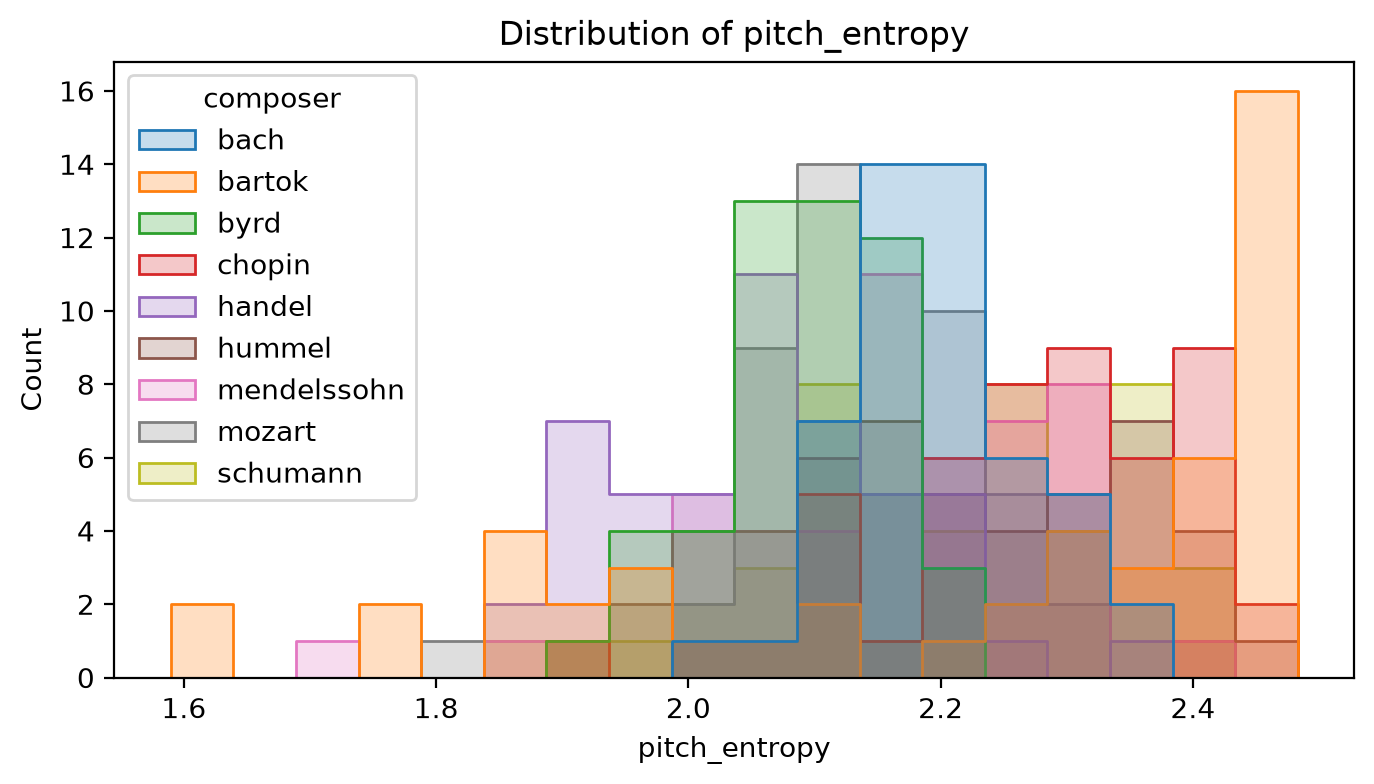

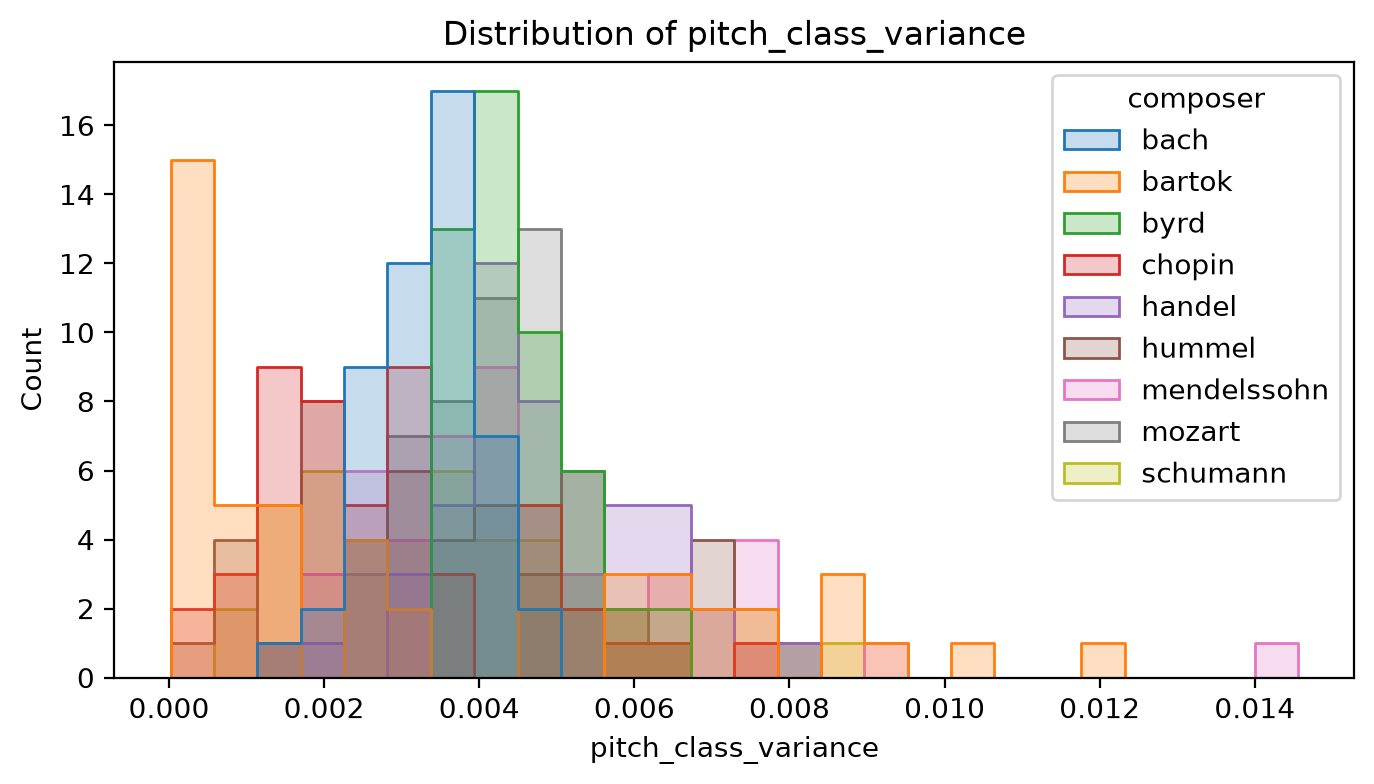

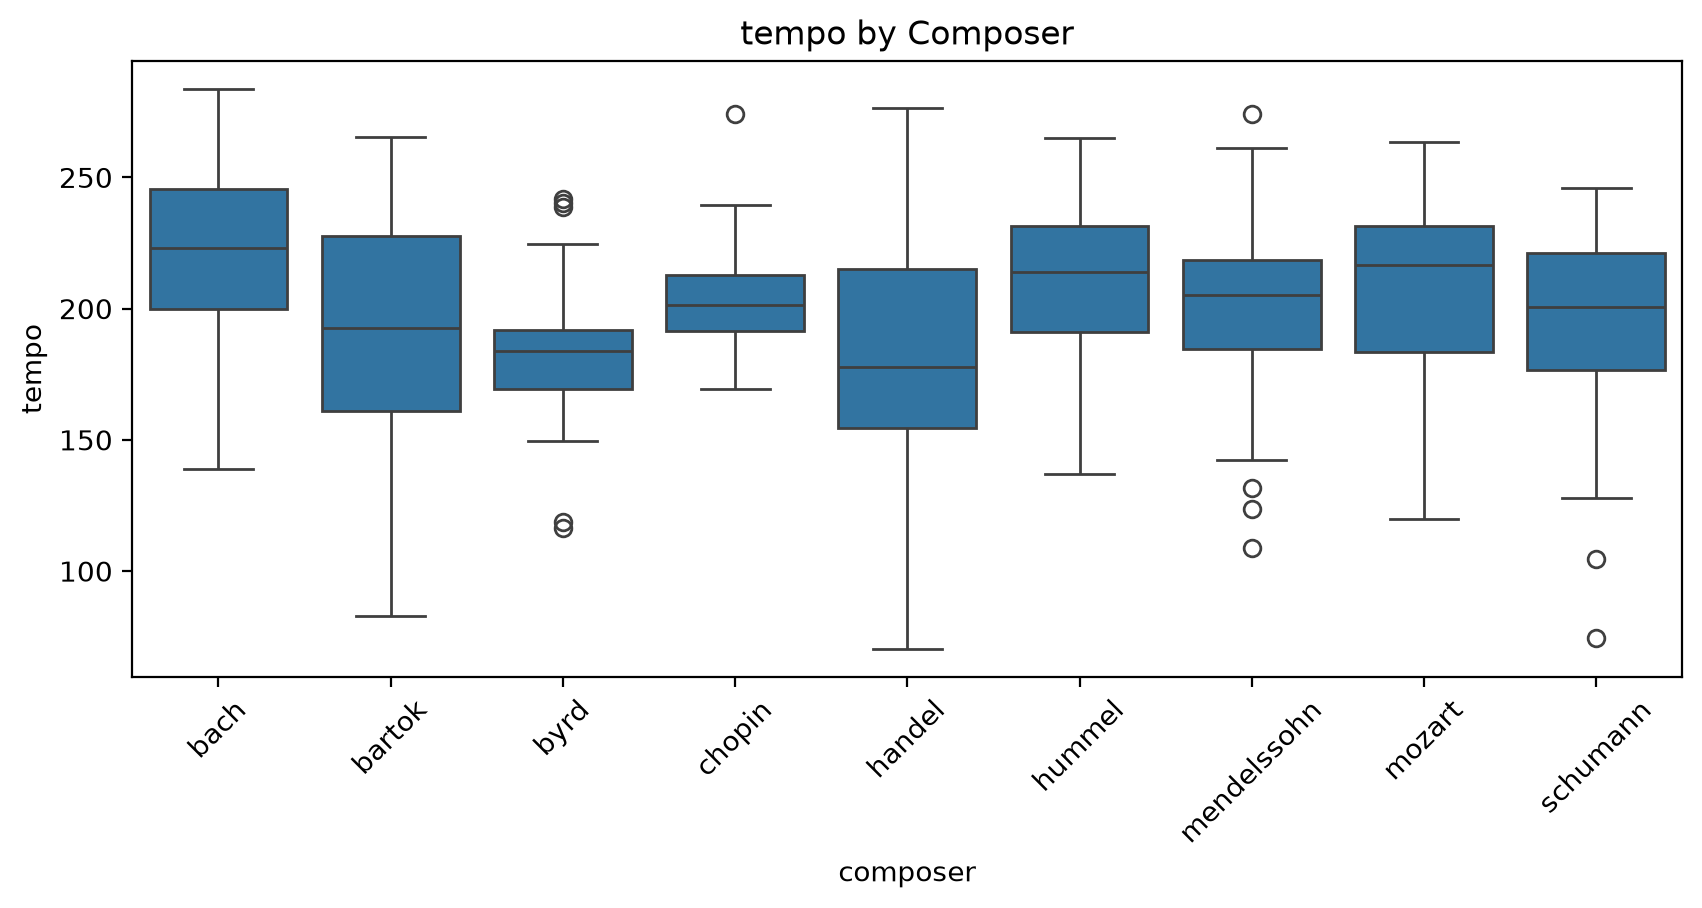

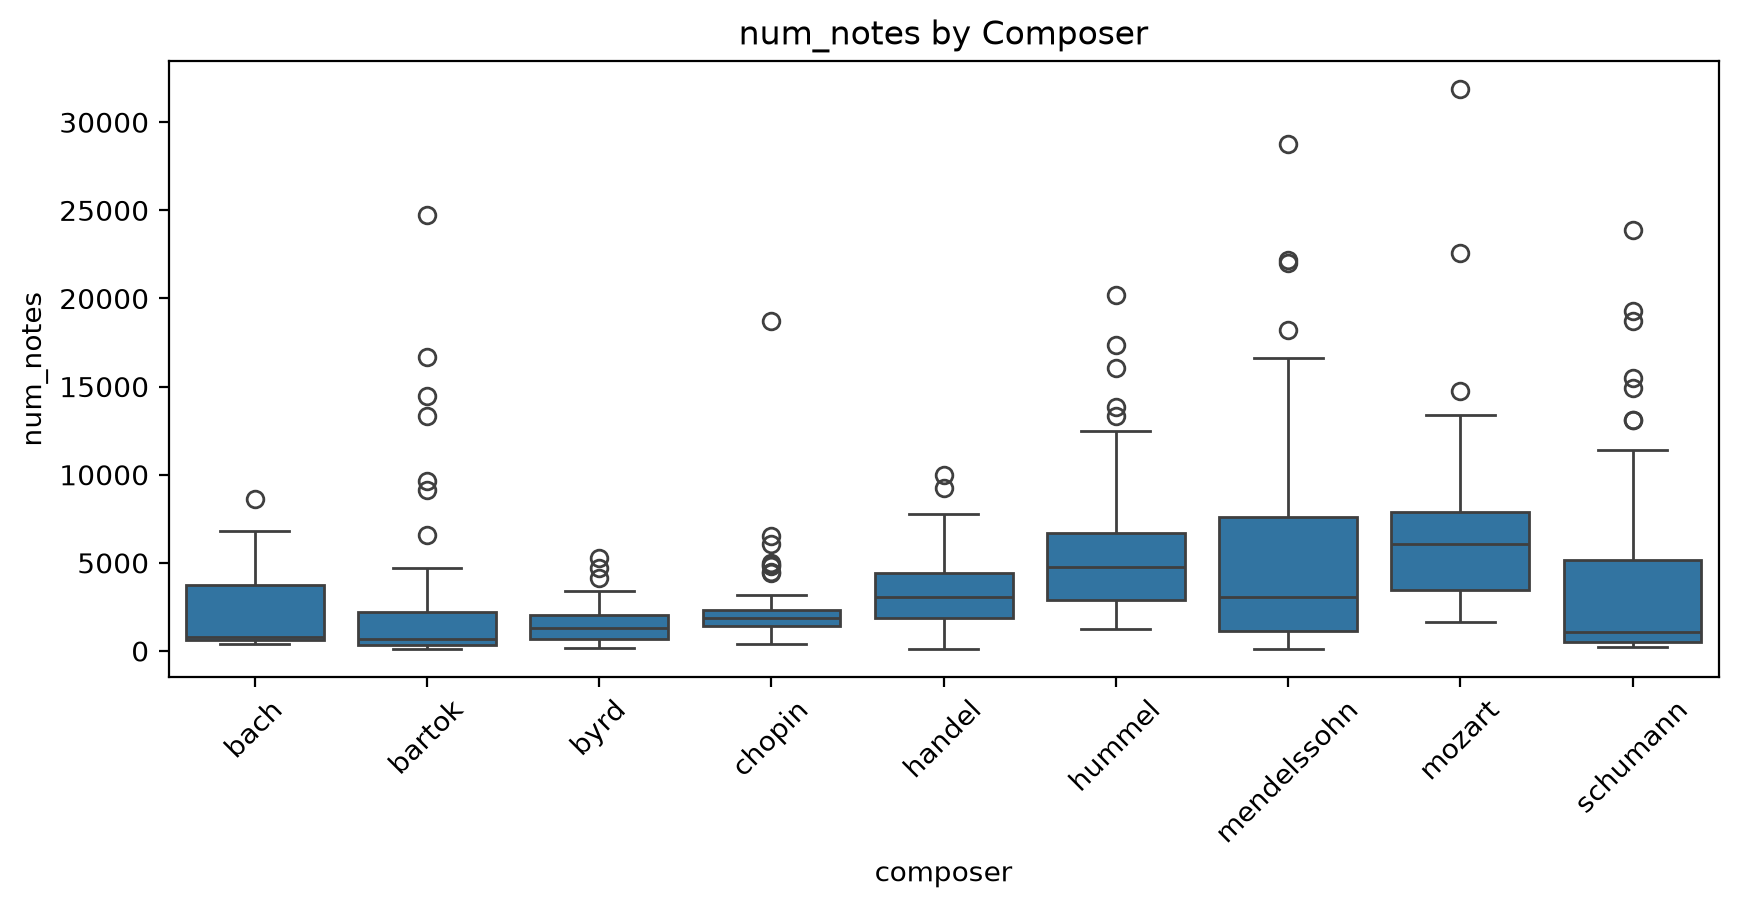

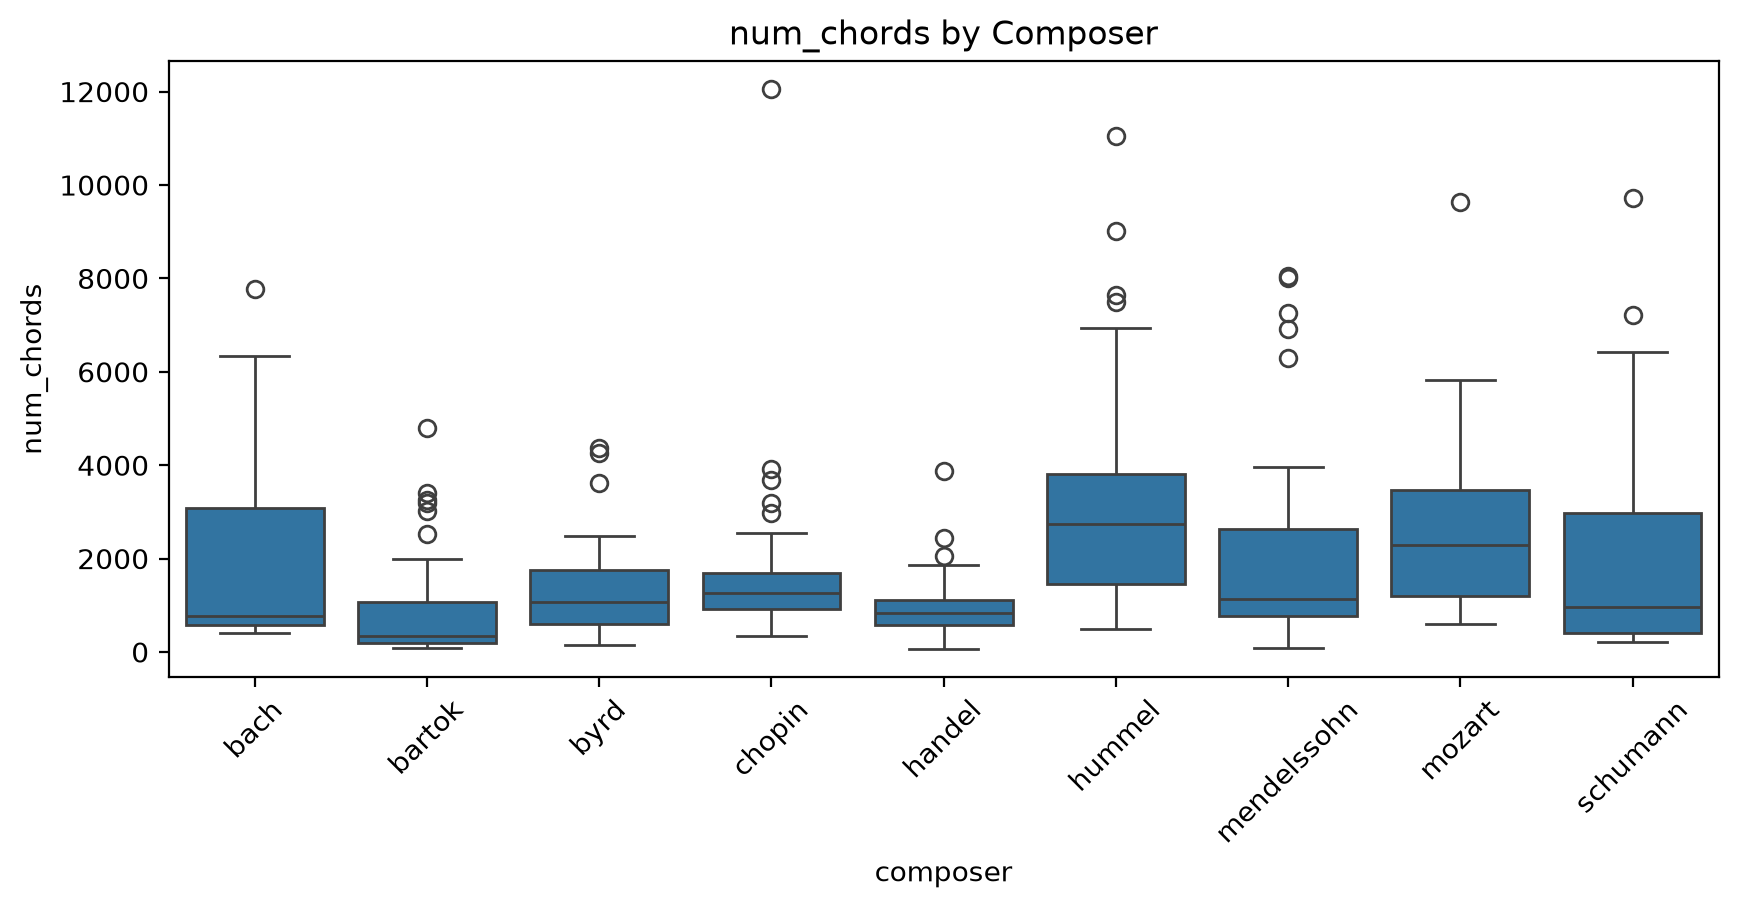

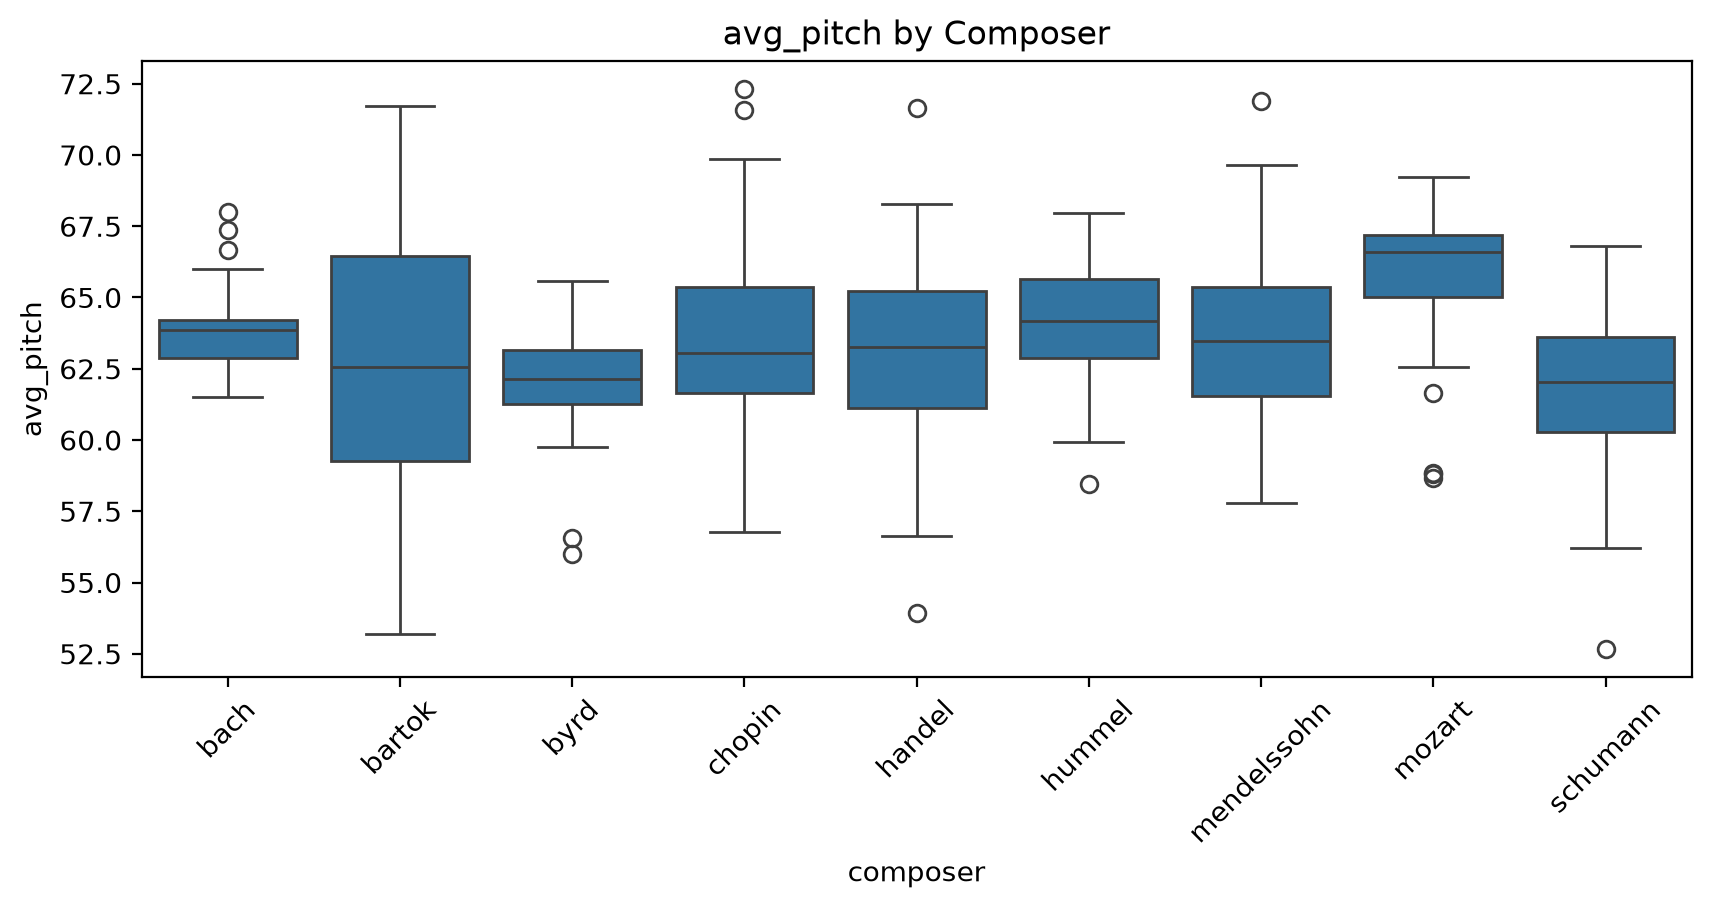

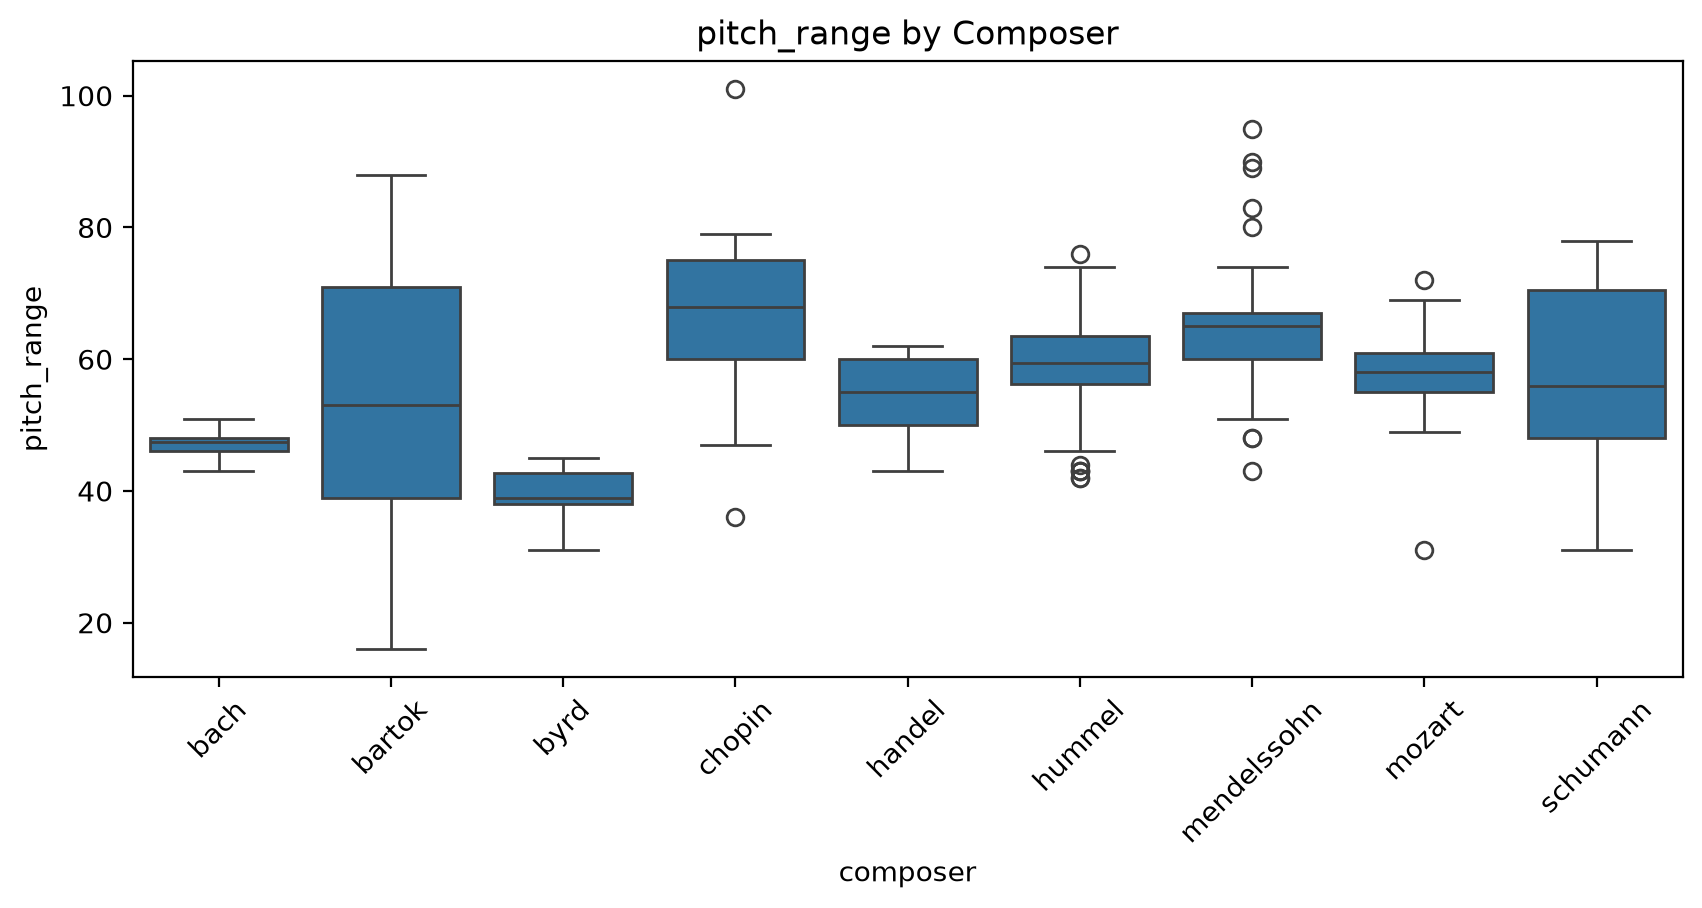

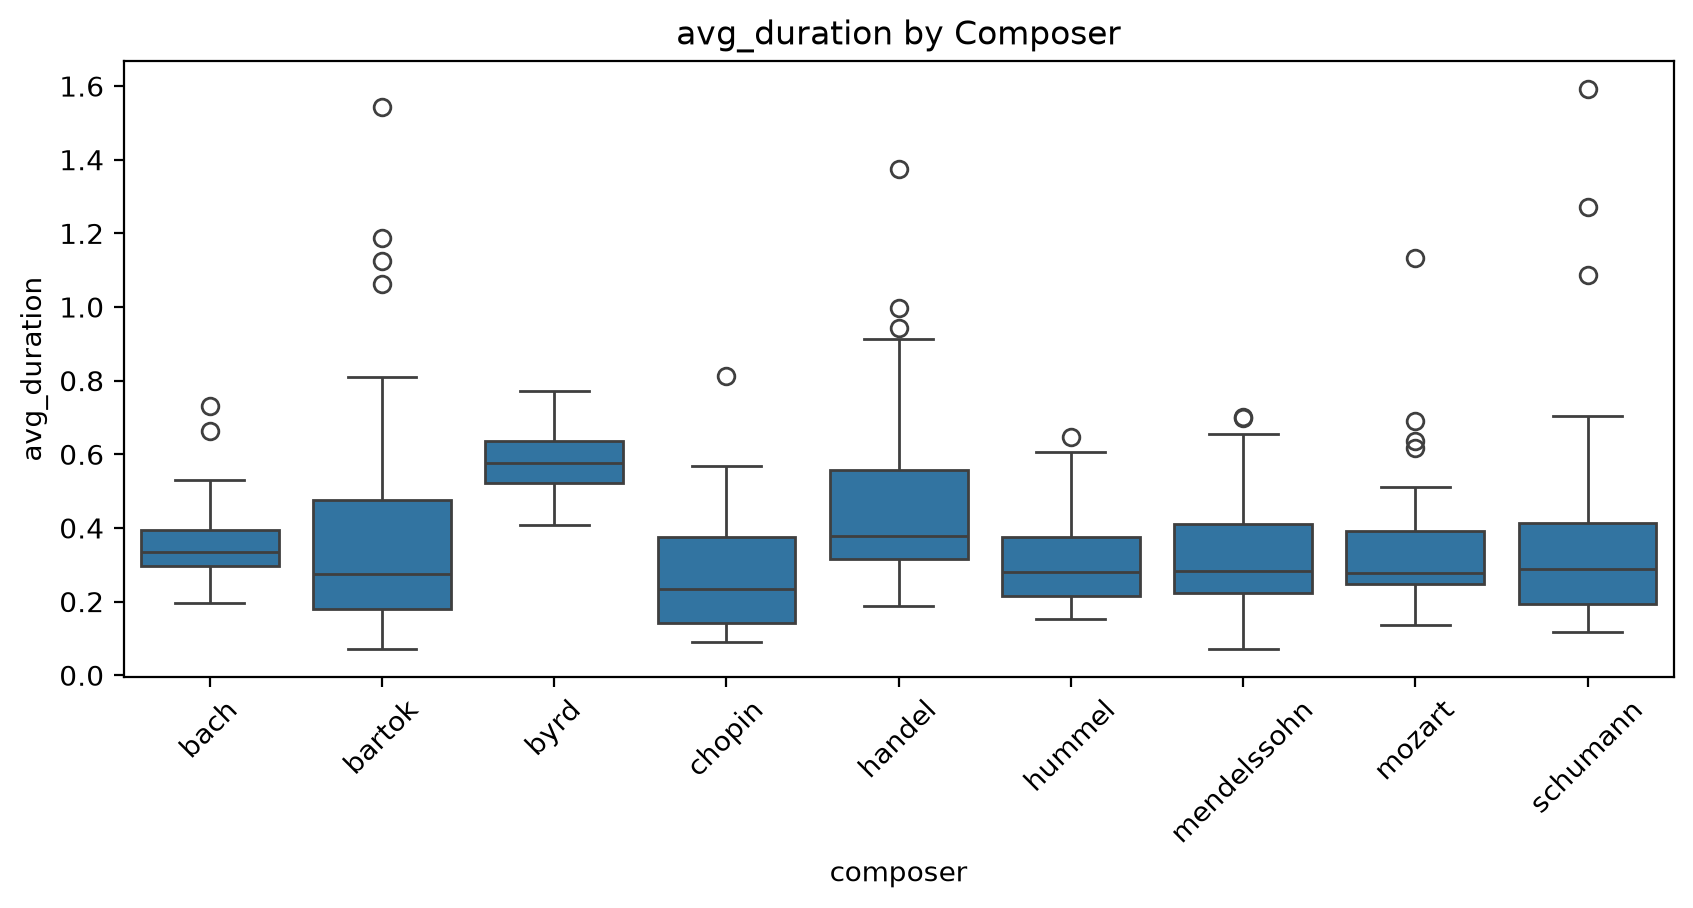

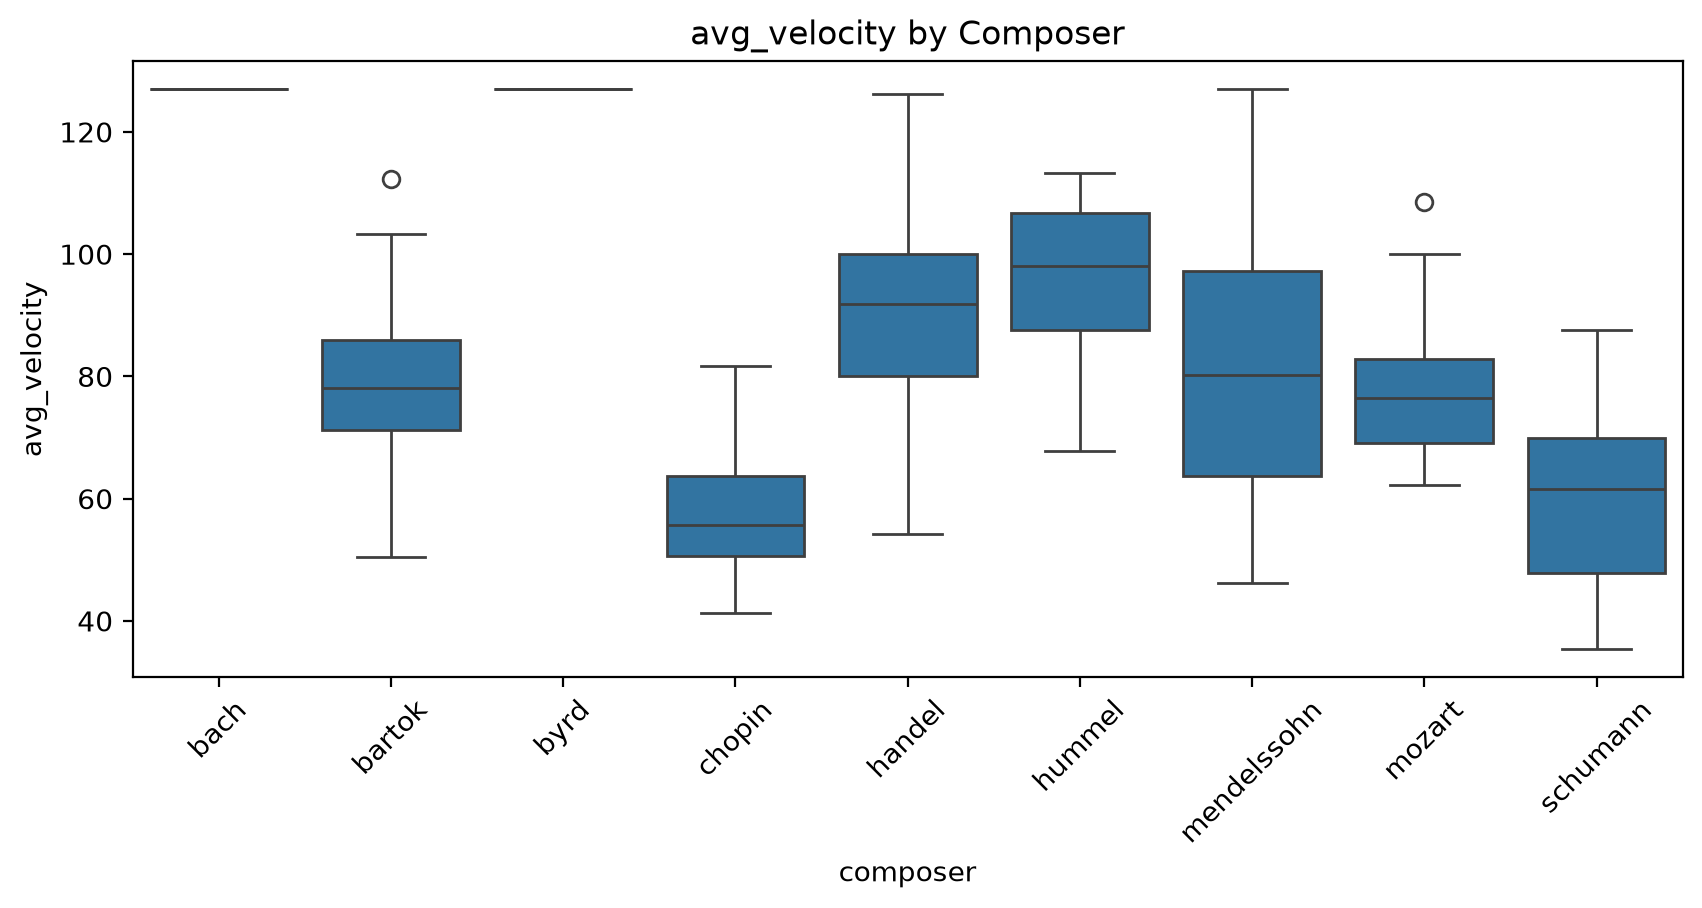

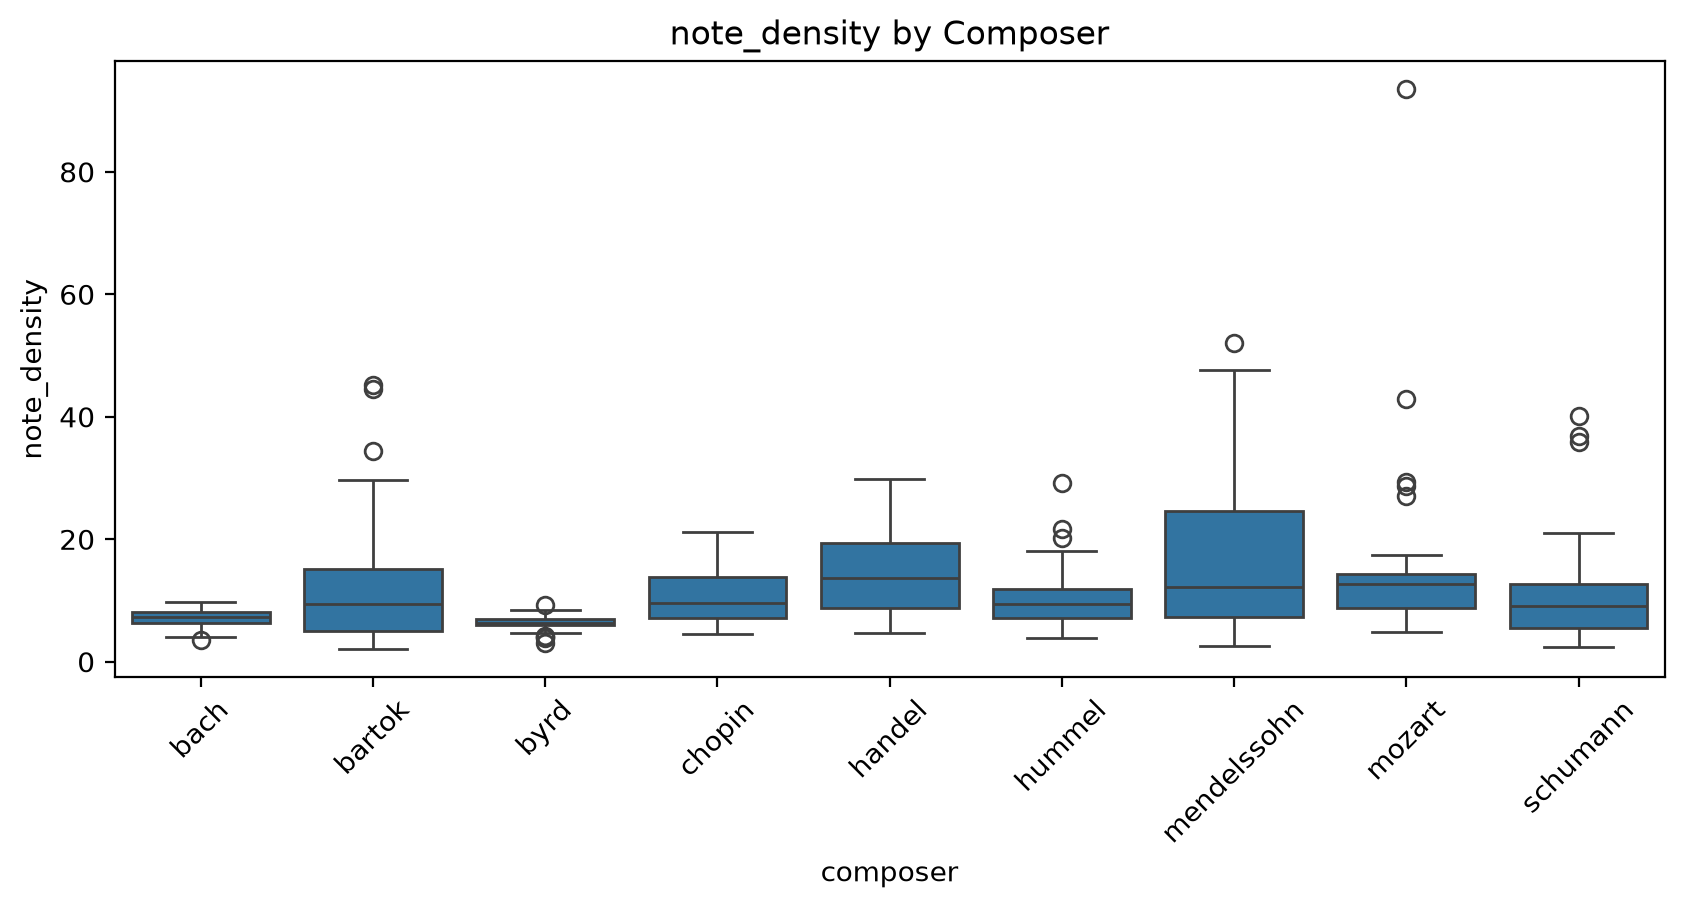

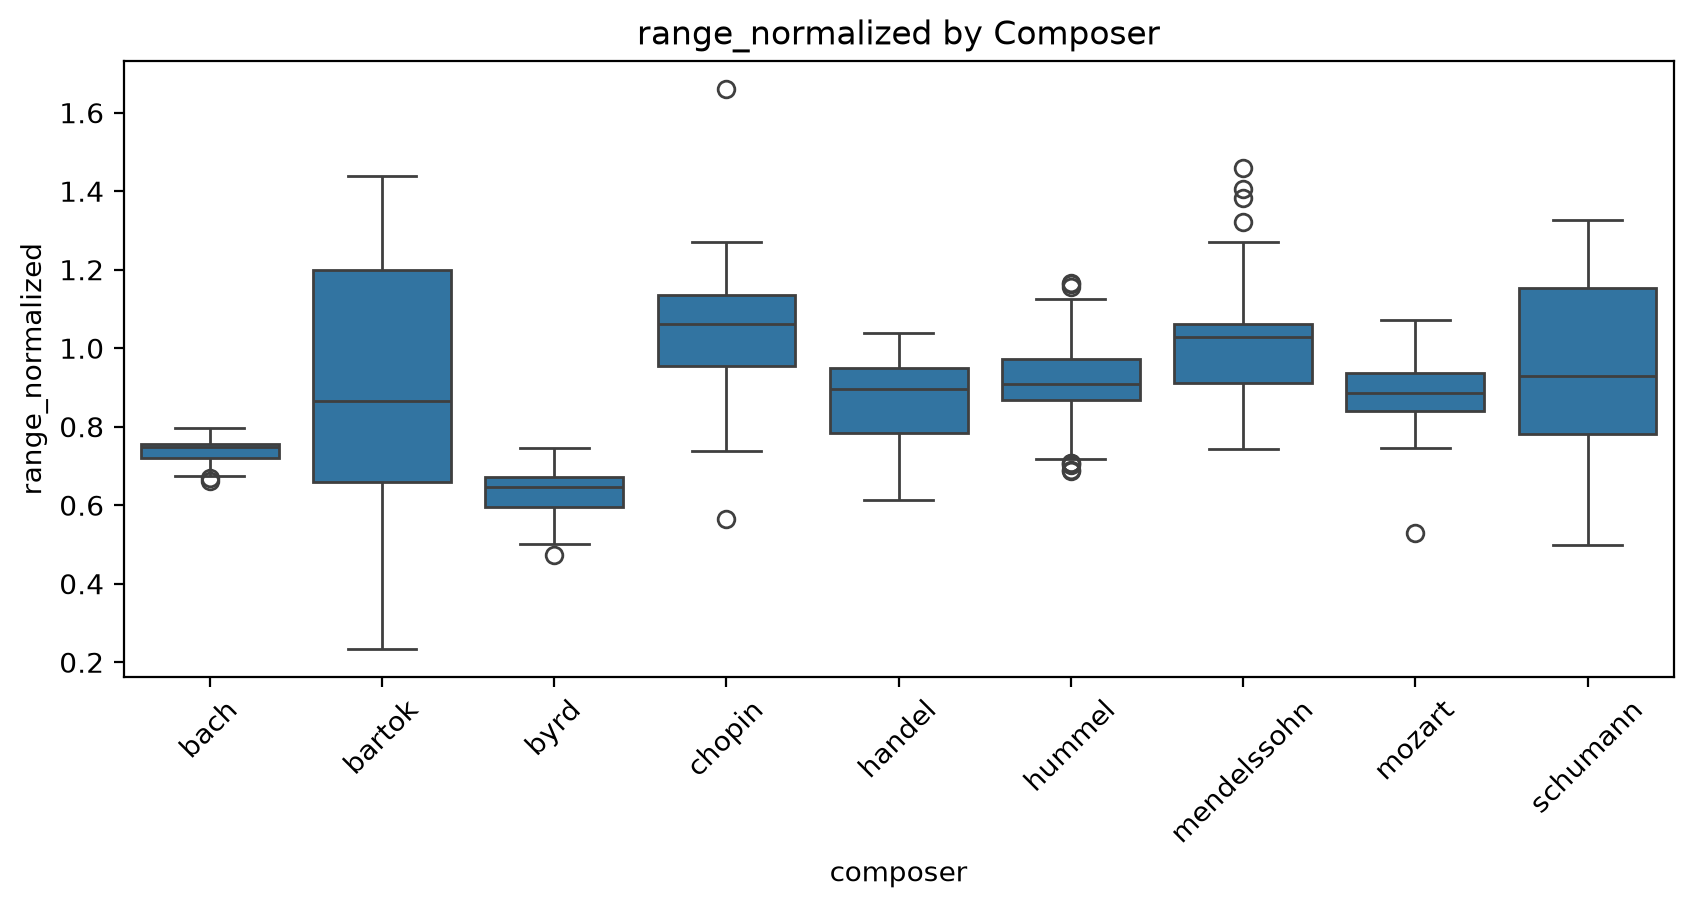

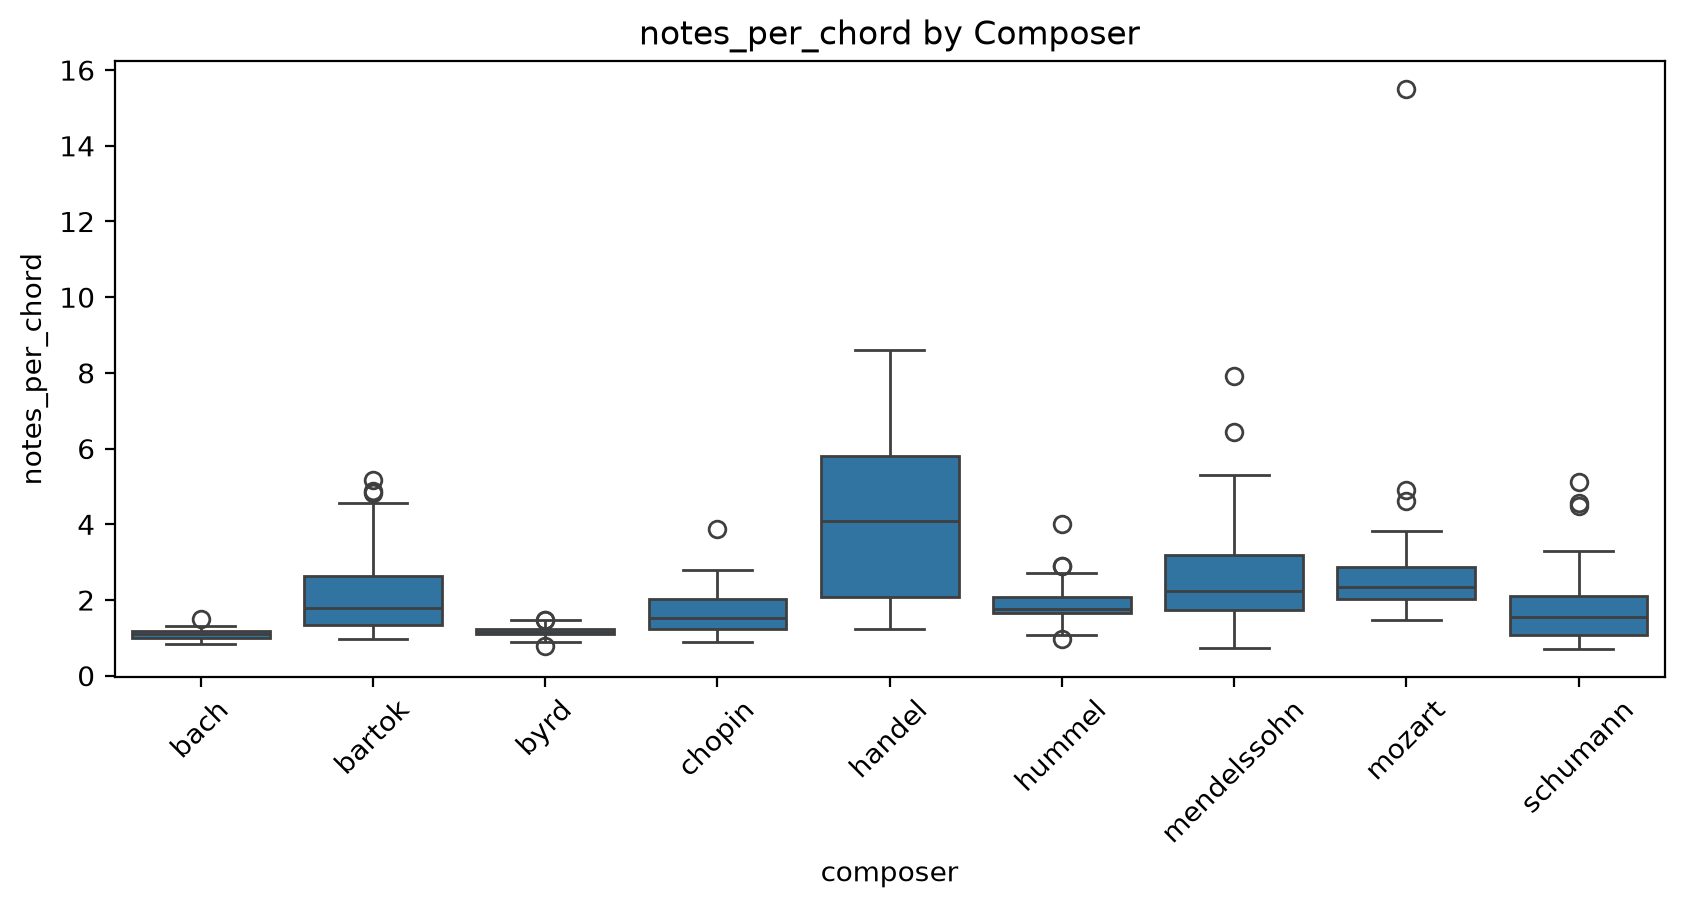

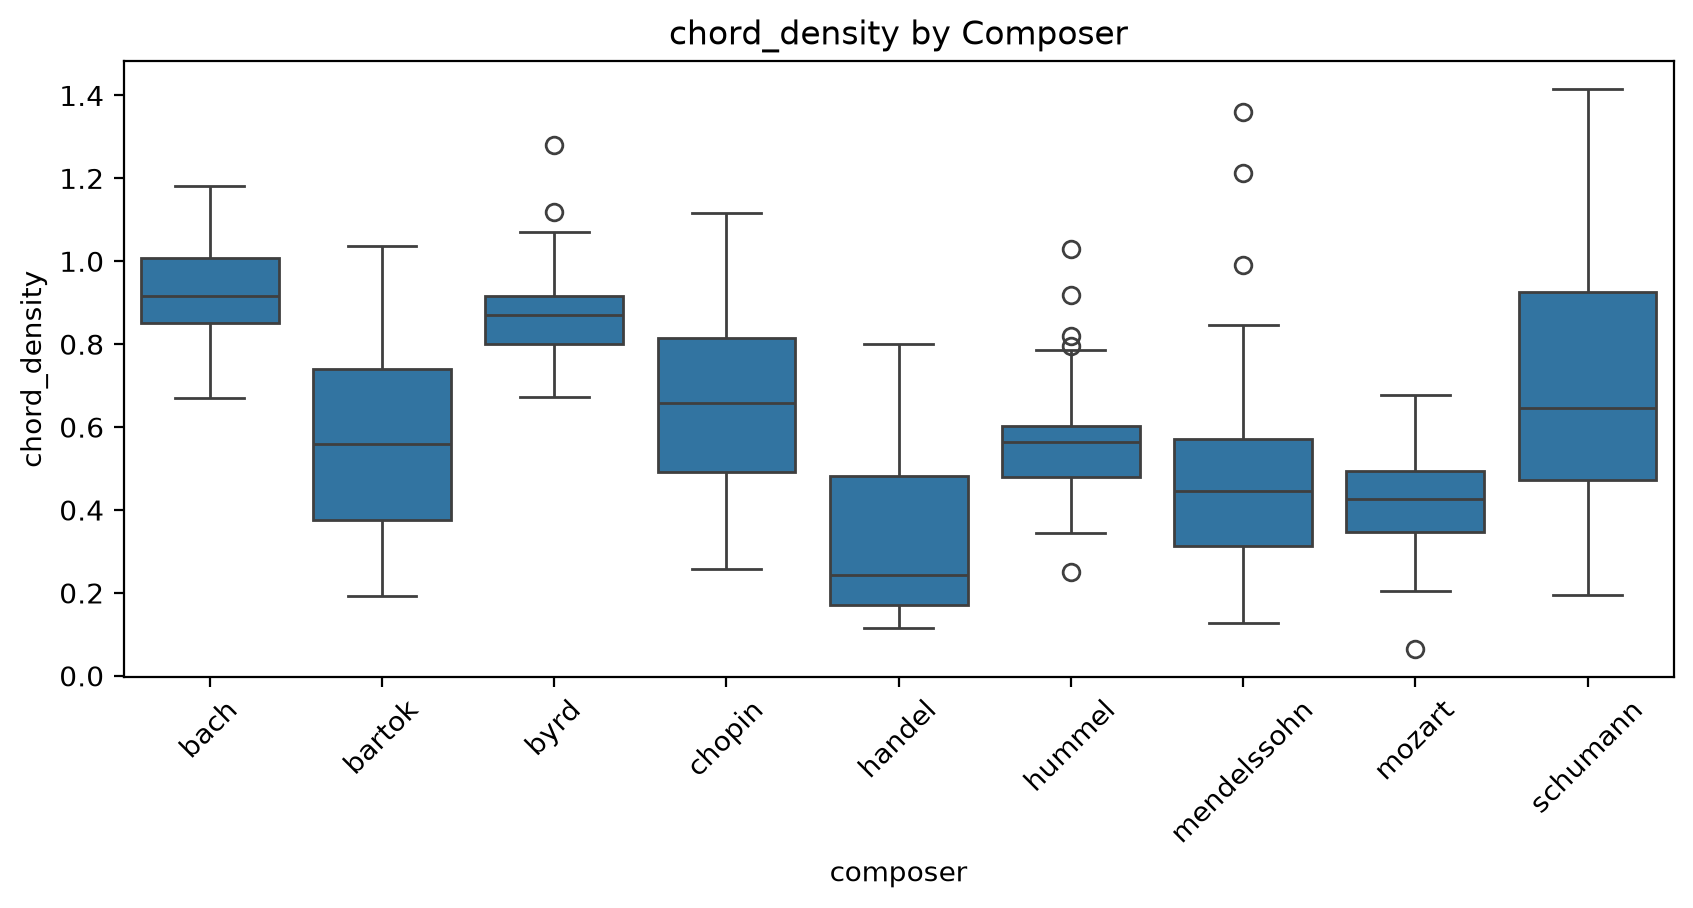

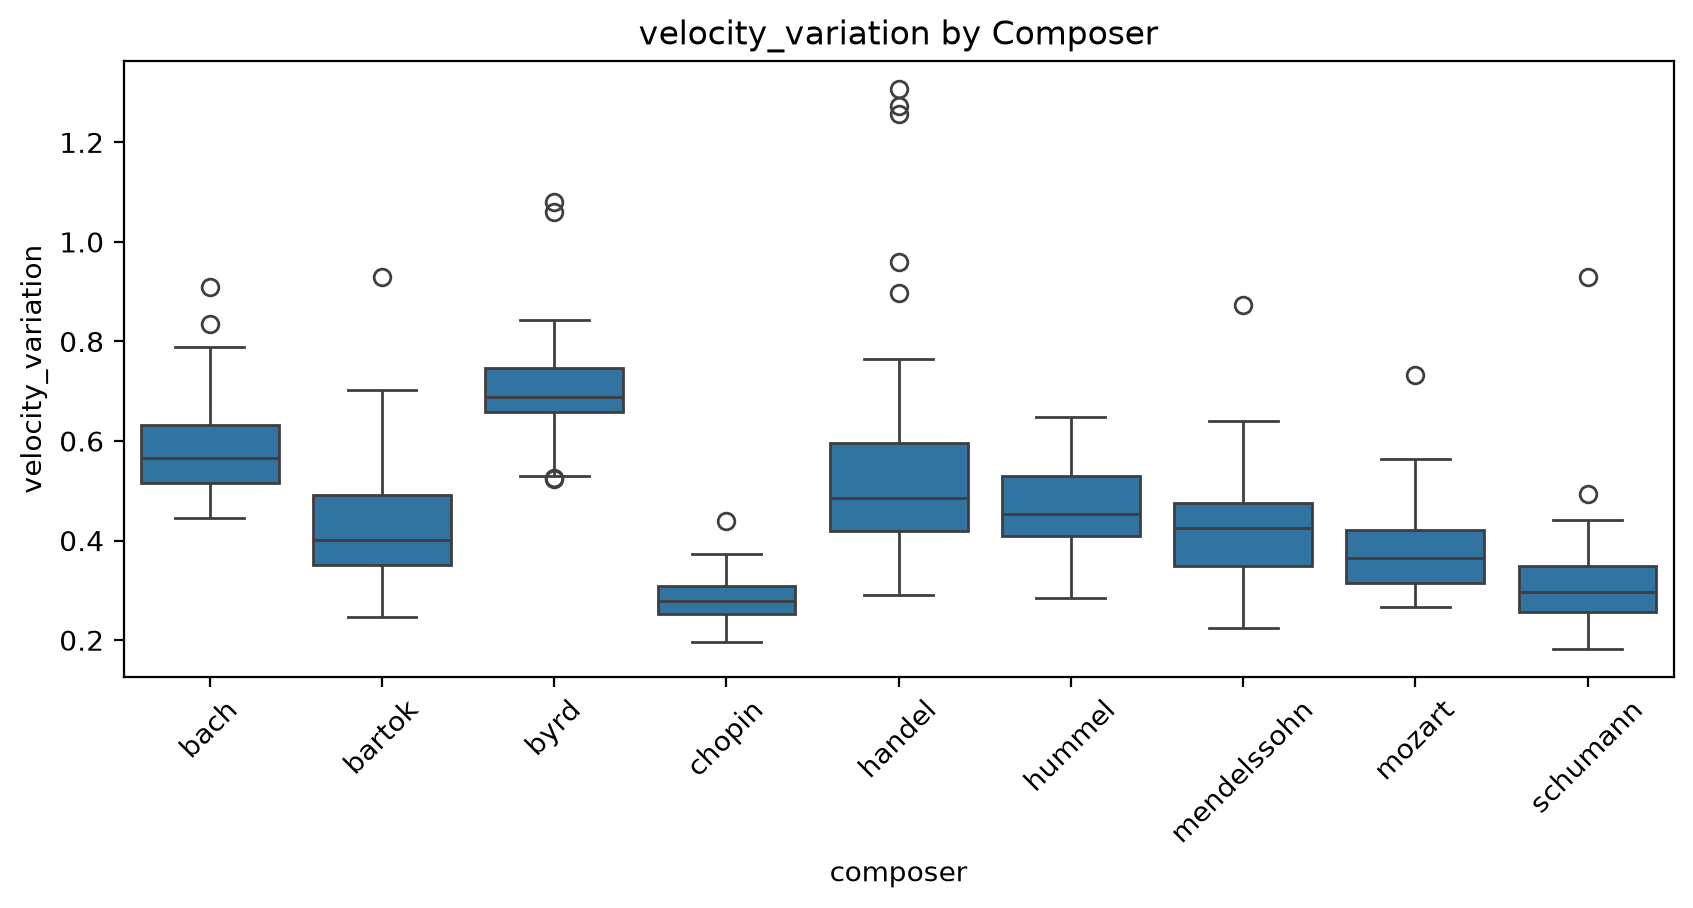

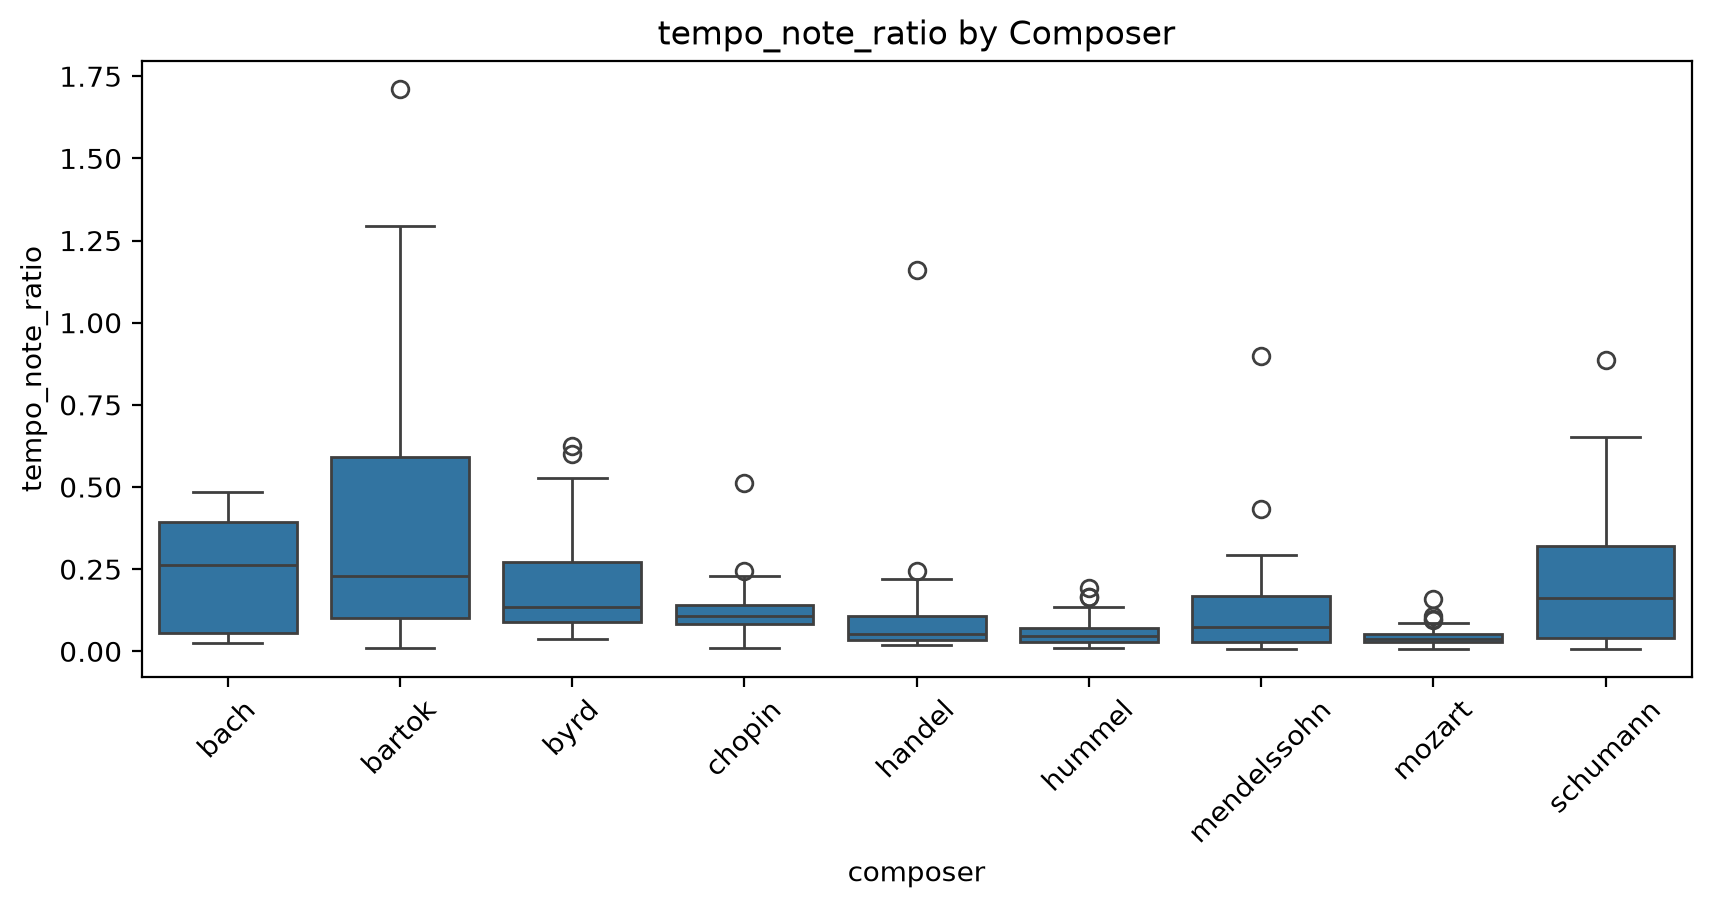

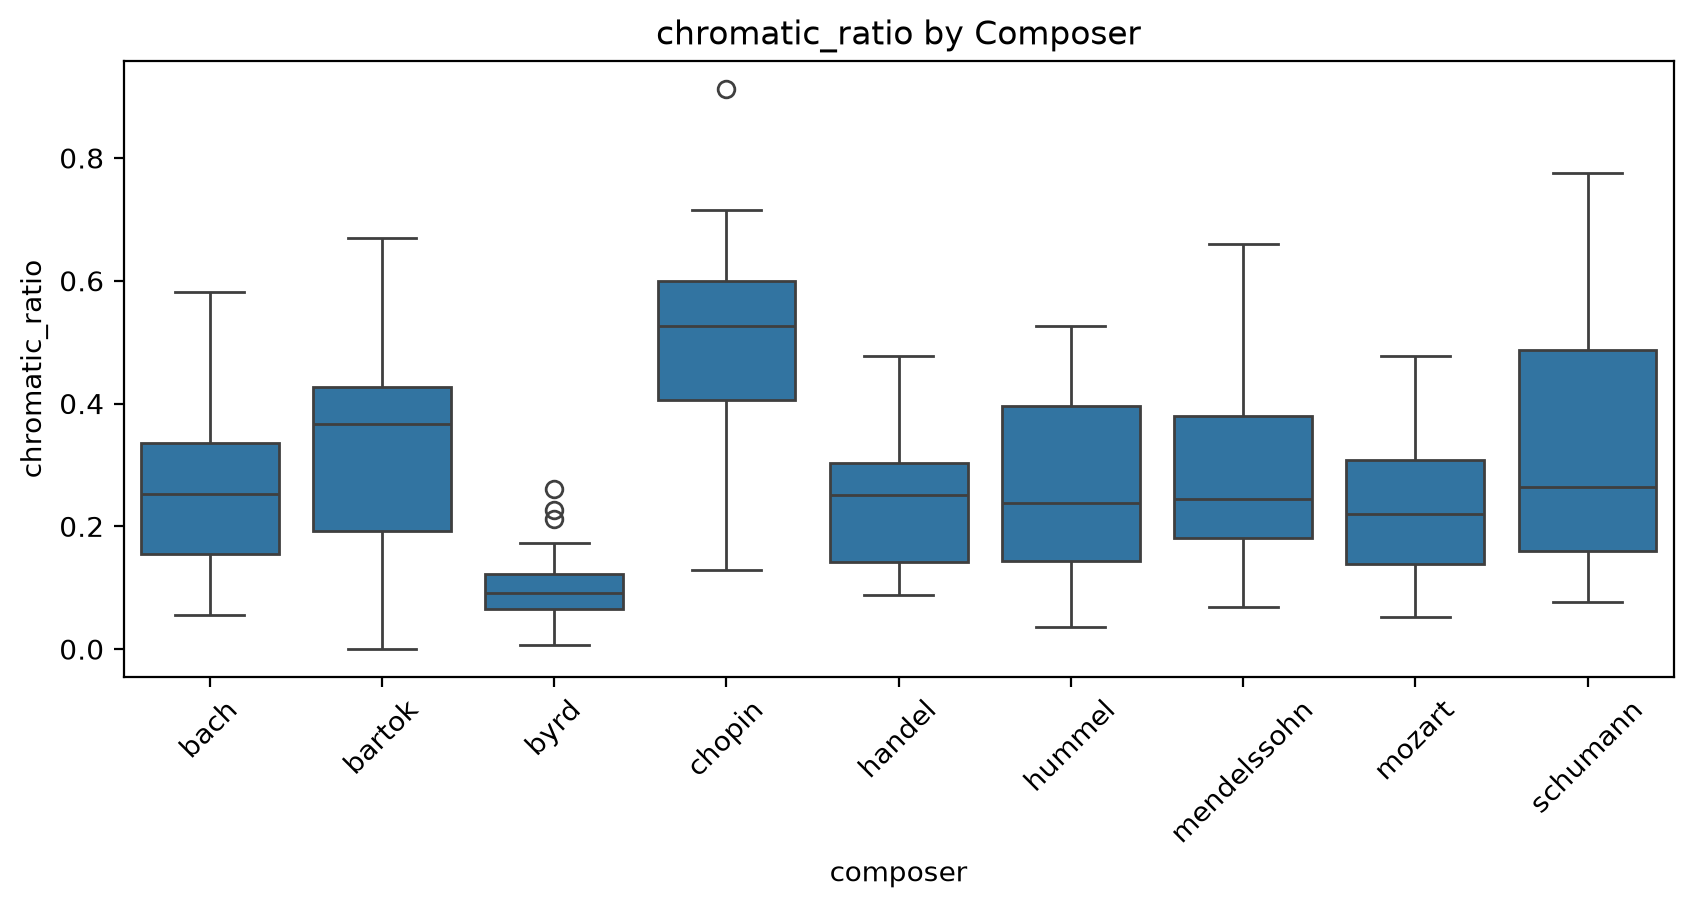

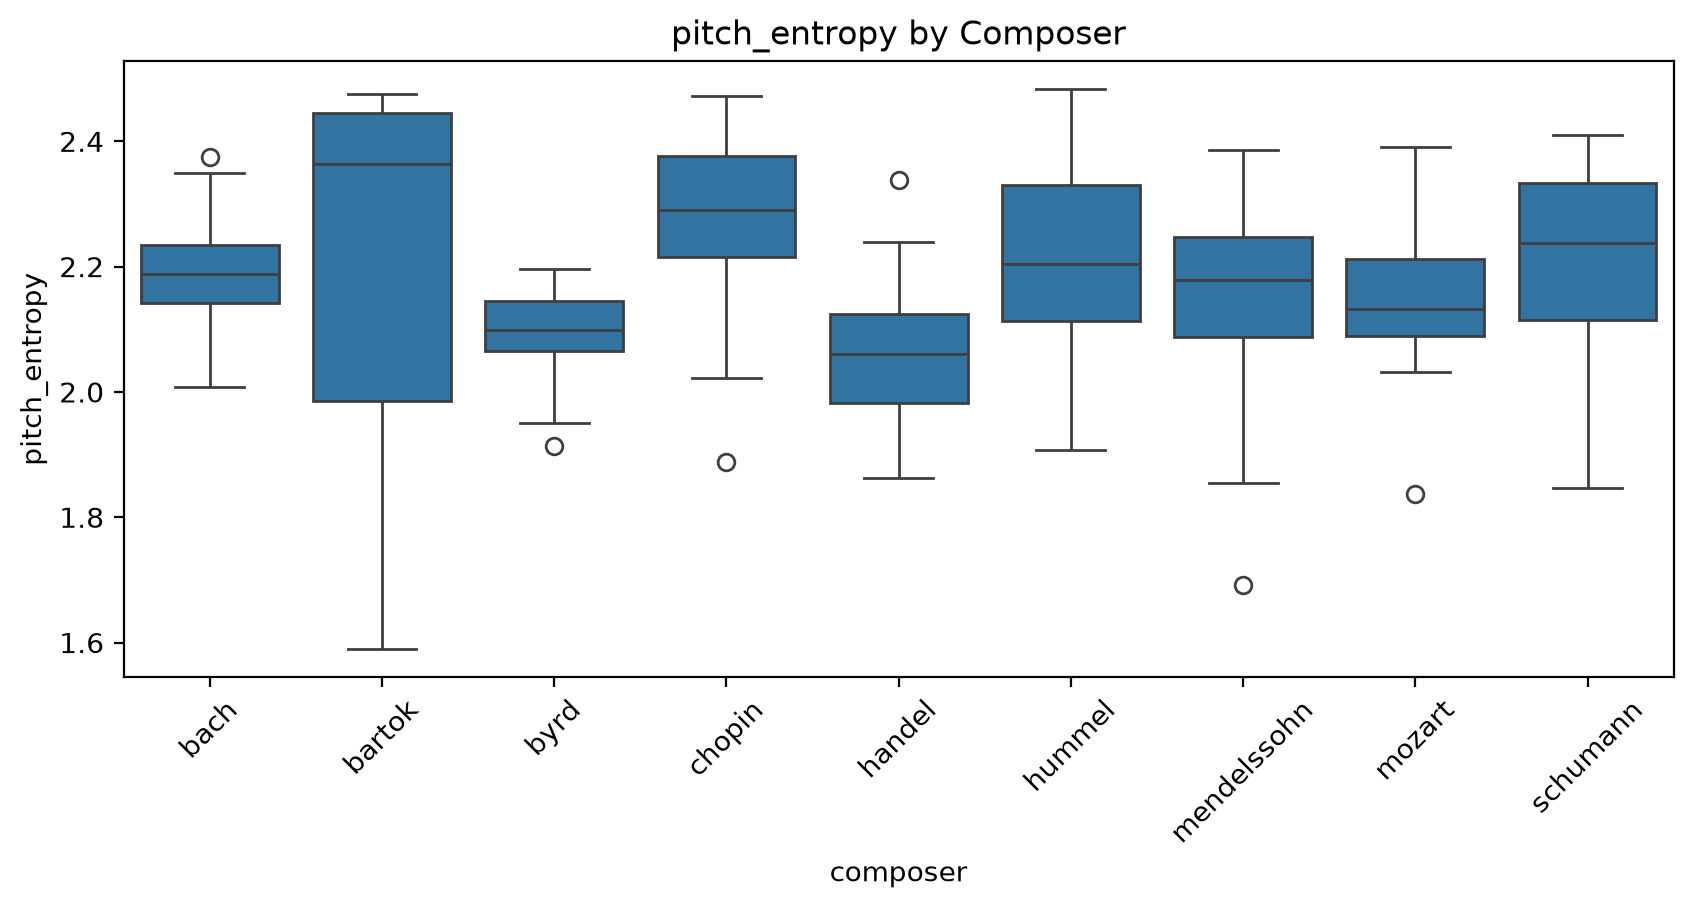

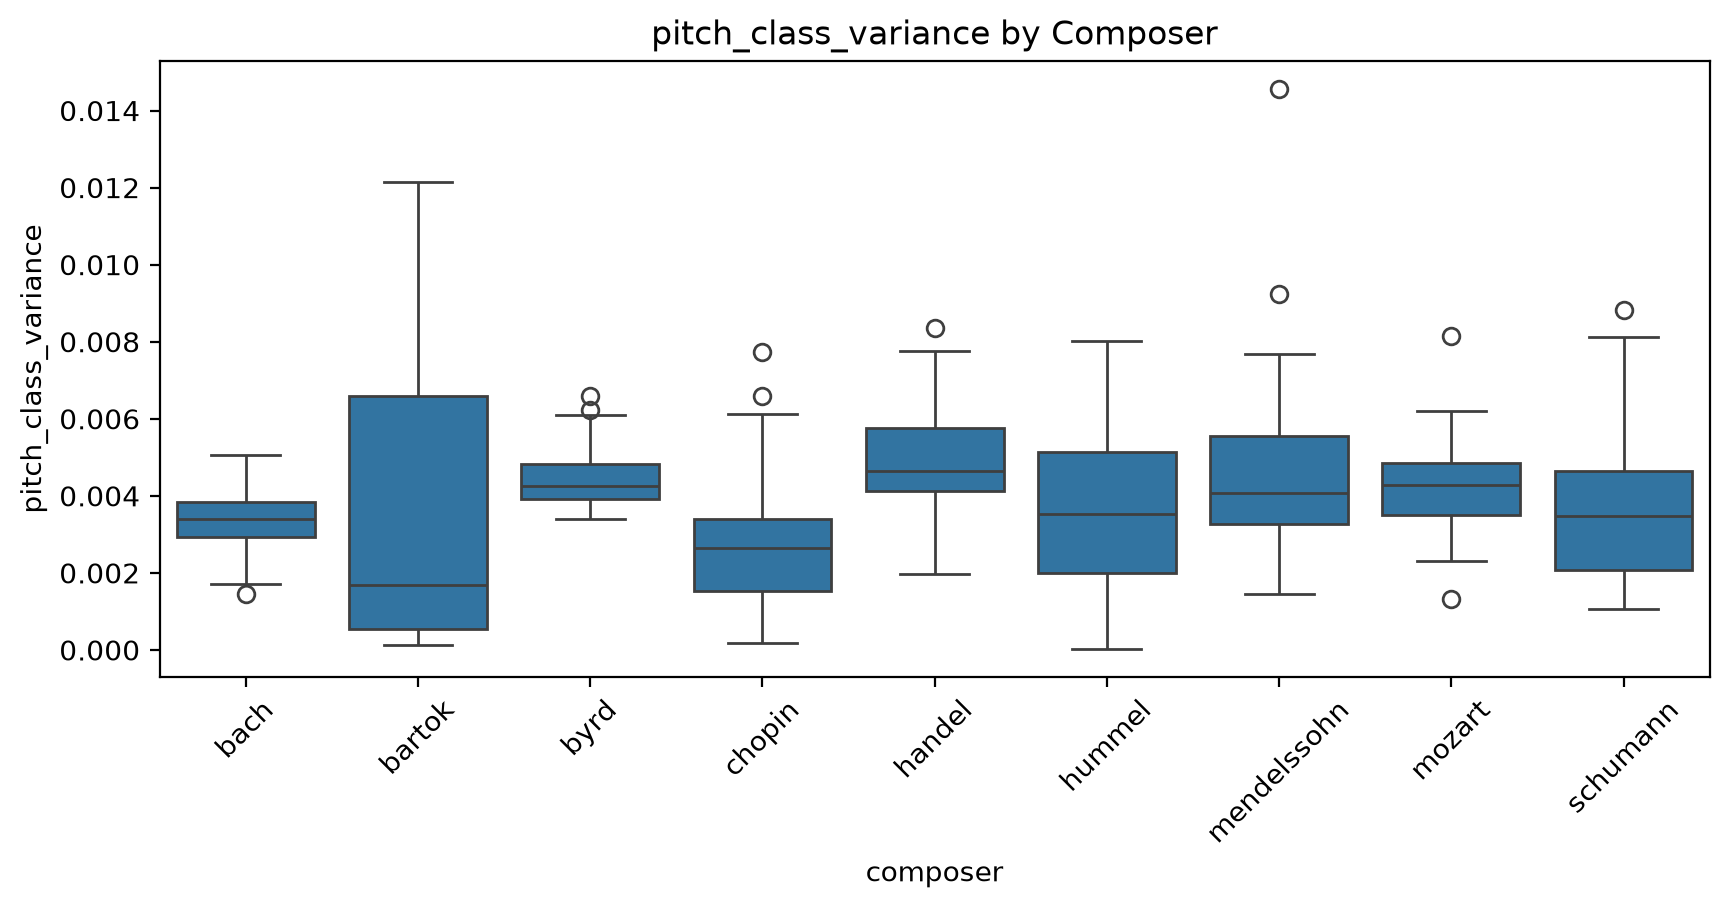

,tempo,num_notes,num_chords,avg_pitch,pitch_range,avg_duration,avg_velocity,note_density,range_normalized,notes_per_chord,chord_density,velocity_variation,tempo_note_ratio,chromatic_ratio,pitch_entropy,pitch_class_variance
composer,,,,,,,,,,,,,,,,
bach,219.449030,2207.780000,1982.000000,63.793044,46.960000,0.354928,127.000000,7.190837,0.736410,1.080687,0.937219,0.590471,0.231679,0.261050,2.193429,0.003338
bartok,192.362648,2783.693878,883.306122,62.817485,53.612245,0.383664,78.694556,12.052727,0.858980,2.197194,0.558171,0.430344,0.399925,0.310020,2.224872,0.003406
byrd,183.582060,1558.960000,1329.700000,62.052898,39.380000,0.579484,127.000000,6.426816,0.635204,1.160318,0.872882,0.702104,0.200374,0.097939,2.094020,0.004428
chopin,203.456913,2557.367347,1623.163265,63.668053,66.714286,0.288772,57.622022,10.659648,1.048734,1.650493,0.675790,0.283413,0.119653,0.499557,2.275613,0.002839
handel,177.953829,3358.795918,910.755102,63.079543,54.612245,0.480072,89.619823,14.567567,0.868838,4.098514,0.323762,0.549654,0.099553,0.241330,2.061680,0.004955
hummel,208.847952,5935.040000,3164.160000,64.094763,58.800000,0.309393,95.733735,10.373355,0.916293,1.889702,0.564817,0.465783,0.057769,0.260297,2.202626,0.003717
mendelssohn,200.905996,5637.020408,2002.040816,63.533034,64.632653,0.322991,81.236544,17.192463,1.017174,2.625660,0.489407,0.411004,0.117463,0.286659,2.160811,0.004573
mozart,208.376708,6775.061224,2621.122449,65.829511,57.938776,0.339621,77.932013,14.763219,0.880388,2.785158,0.415140,0.382323,0.045636,0.229140,2.150257,0.004199
schumann,195.897144,4368.795455,2014.045455,61.891186,58.931818,0.374382,59.590750,11.002432,0.952850,1.816571,0.692256,0.314722,0.210910,0.323748,2.208995,0.003717


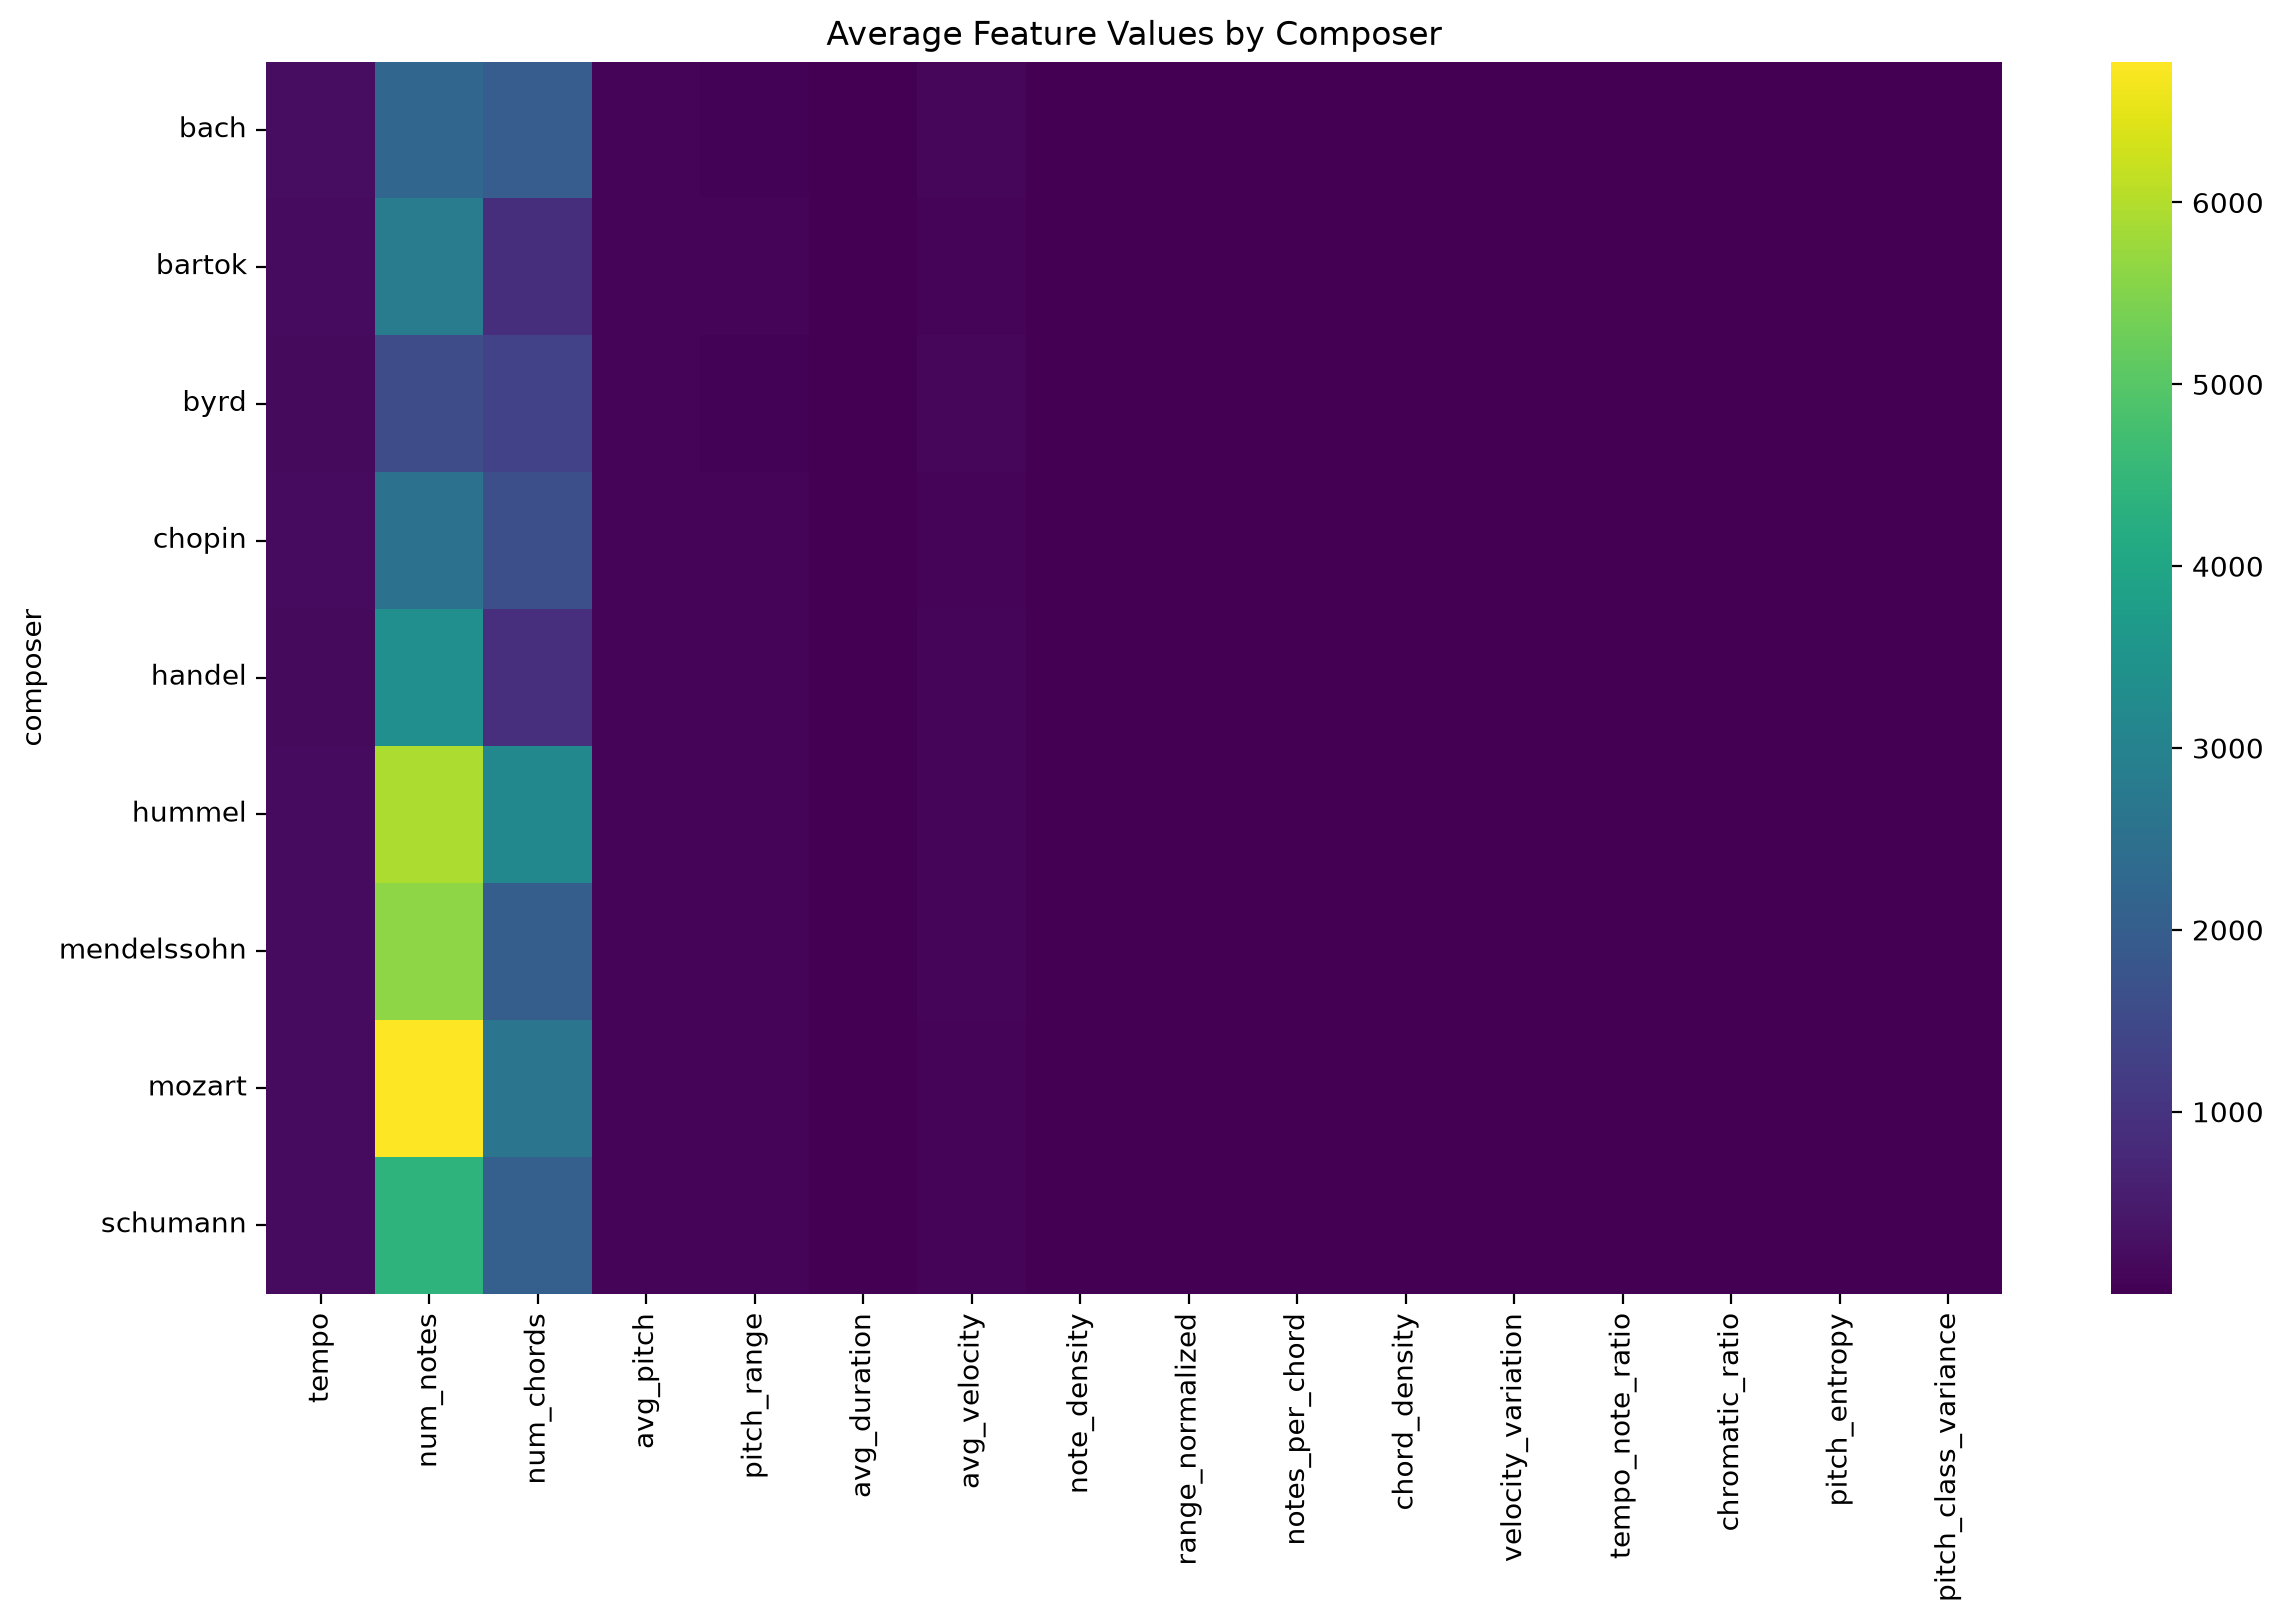

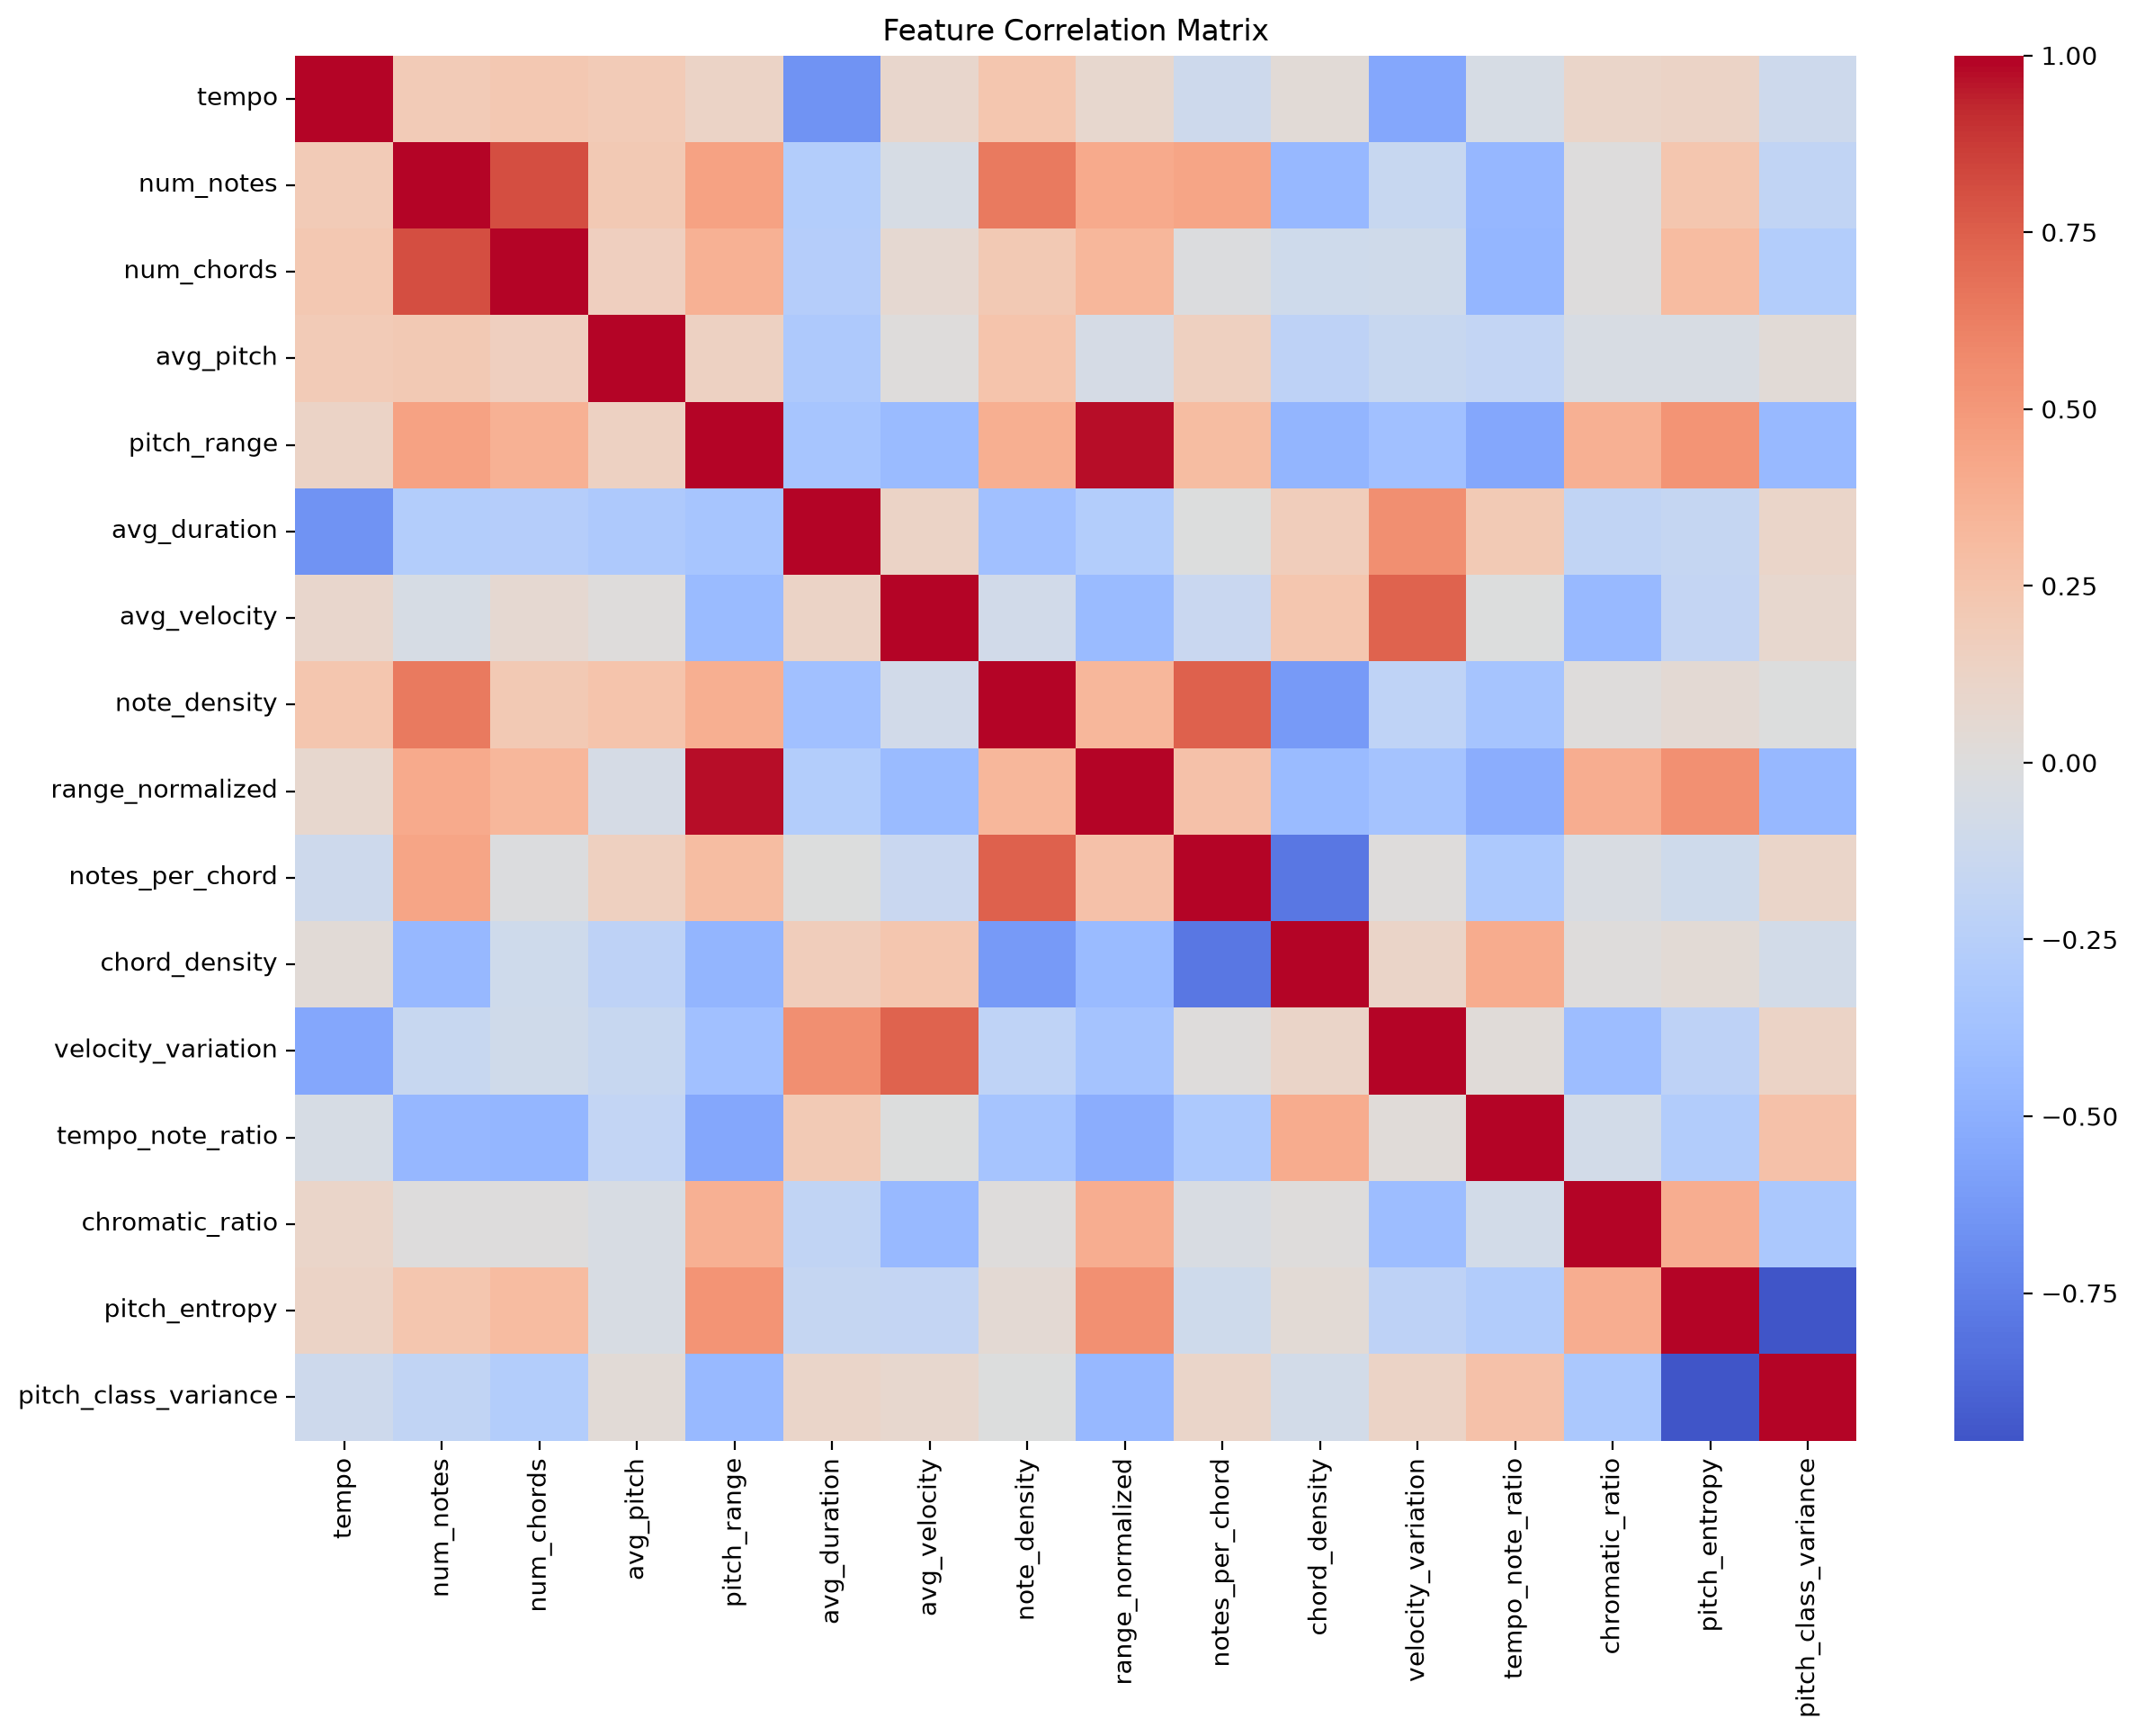

Most discriminative features:


,feature,F_score,p_value
6,avg_velocity,216.187011,1.792124e-145
11,velocity_variation,58.836443,2.254659e-64
10,chord_density,51.843523,1.819760e-58
4,pitch_range,33.651861,3.997401e-41
8,range_normalized,30.949264,2.932895e-38
9,notes_per_chord,30.474754,9.532894e-38
13,chromatic_ratio,29.016210,3.713318e-36
12,tempo_note_ratio,17.345754,1.981843e-22
14,pitch_entropy,11.163657,2.218649e-14
5,avg_duration,10.863370,5.628155e-14


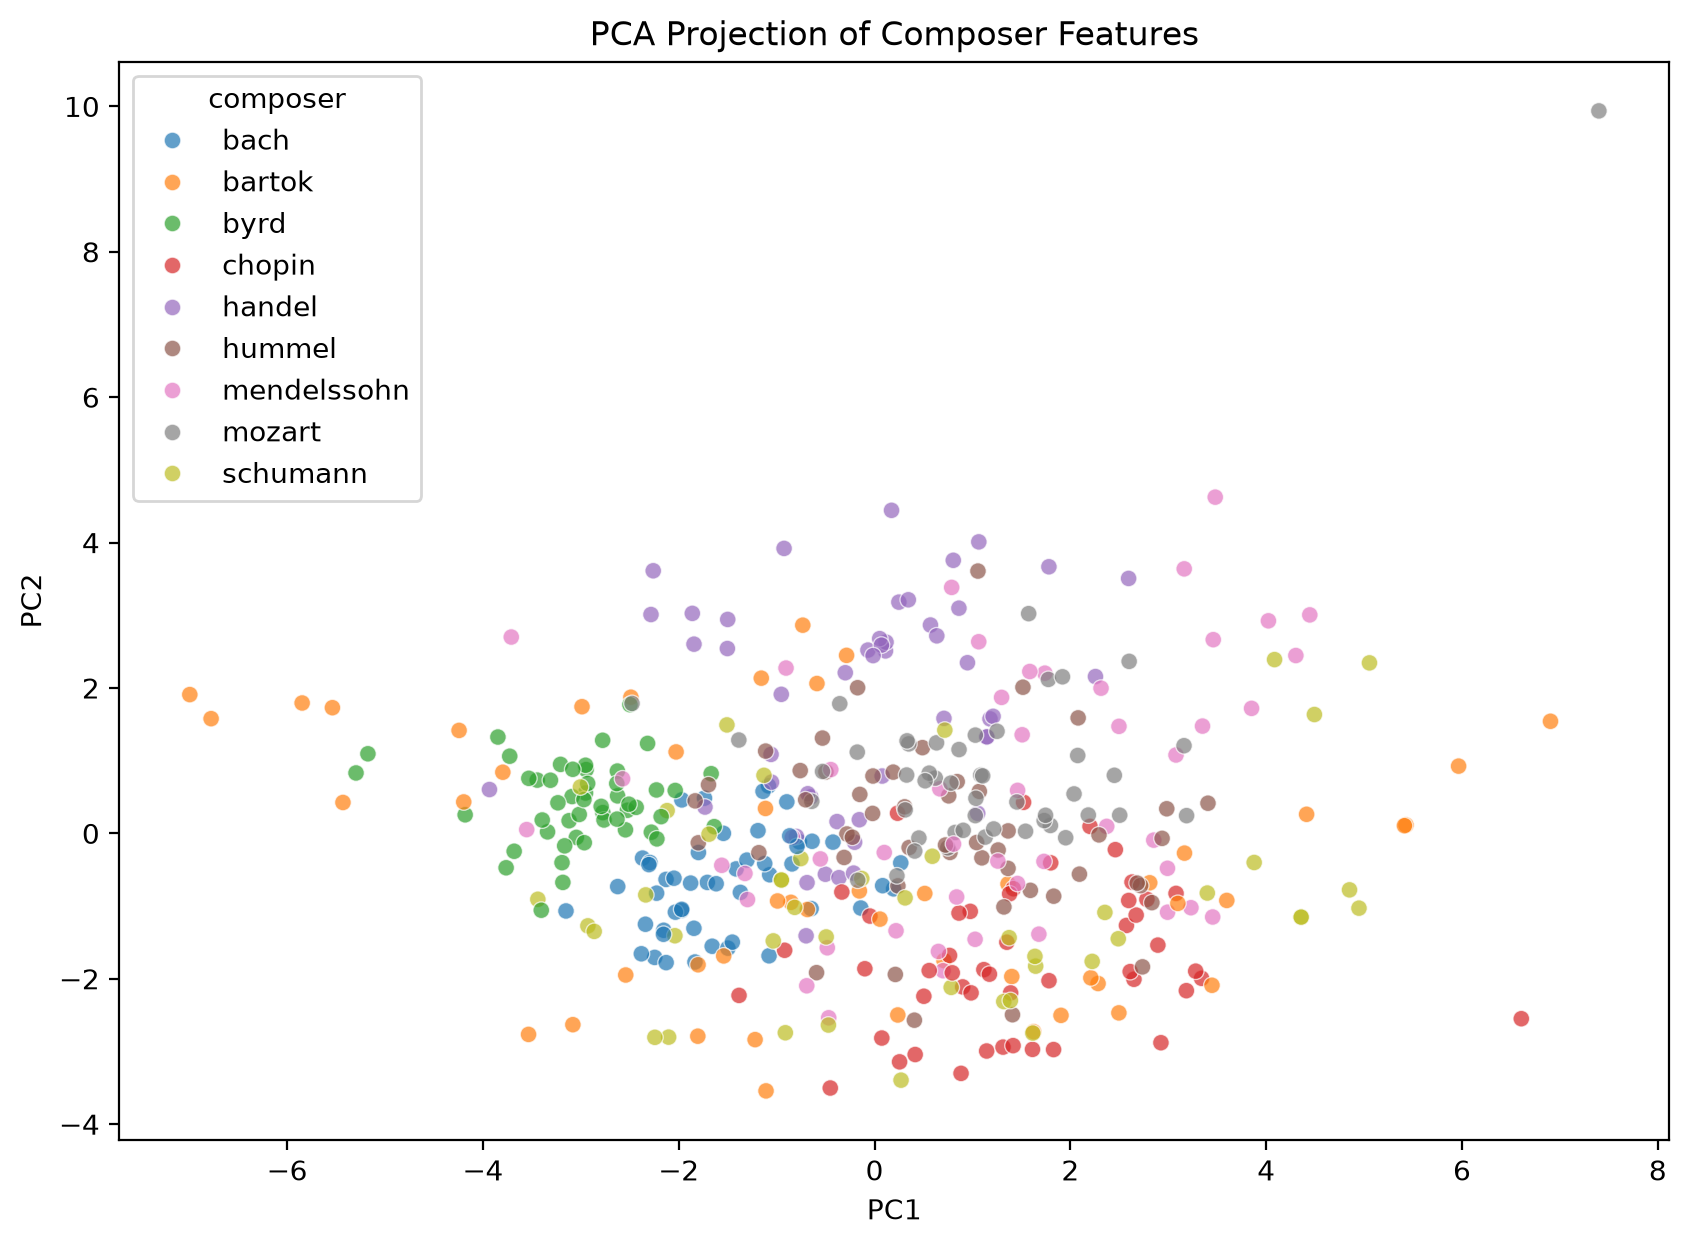

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load data
# -----------------------------

train = pd.read_csv("data/train_features.csv")
dev = pd.read_csv("data/dev_features.csv")
test = pd.read_csv("data/test_features.csv")

df = pd.concat(
    [train, dev, test],
    ignore_index=True
)

print("Dataset shape:", df.shape)

print("\nComposer counts:")
print(df["composer"].value_counts())


# -----------------------------
# Basic statistics
# -----------------------------

print("\nFeature summary:")
display(
    df.describe()
)


# -----------------------------
# Missing values
# -----------------------------

print("\nMissing values:")
display(
    df.isnull().sum()
)


# -----------------------------
# Feature list
# -----------------------------

features = [
    "tempo",
    "num_notes",
    "num_chords",
    "avg_pitch",
    "pitch_range",
    "avg_duration",
    "avg_velocity",
    "note_density",
    "range_normalized",
    "notes_per_chord",
    "chord_density",
    "velocity_variation",
    "tempo_note_ratio",
    "chromatic_ratio",
    "pitch_entropy",
    "pitch_class_variance"
]


# -----------------------------
# Histograms
# -----------------------------

for feature in features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=feature,
        hue="composer",
        kde=False,
        element="step"
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.show()


# -----------------------------
# Boxplots by composer
# -----------------------------

for feature in features:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        data=df,
        x="composer",
        y=feature
    )

    plt.xticks(rotation=45)

    plt.title(
        f"{feature} by Composer"
    )

    plt.show()


# -----------------------------
# Composer mean comparison
# -----------------------------

composer_means = (
    df
    .groupby("composer")[features]
    .mean()
)


display(
    composer_means.style.background_gradient(
        cmap="viridis"
    )
)


# -----------------------------
# Heatmap of composer averages
# -----------------------------

plt.figure(
    figsize=(14,8)
)

sns.heatmap(
    composer_means,
    cmap="viridis",
    annot=False
)

plt.title(
    "Average Feature Values by Composer"
)

plt.show()



# -----------------------------
# Correlation matrix
# -----------------------------

plt.figure(
    figsize=(14,10)
)

sns.heatmap(
    df[features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()



# -----------------------------
# Top features separating composers
# ANOVA F-score
# -----------------------------

from sklearn.feature_selection import f_classif

X = df[features]

y = df["composer"]


scores, pvalues = f_classif(
    X,
    y
)


importance = pd.DataFrame({
    "feature": features,
    "F_score": scores,
    "p_value": pvalues
})


importance = importance.sort_values(
    "F_score",
    ascending=False
)


print(
    "Most discriminative features:"
)

display(
    importance
)



# -----------------------------
# PCA visualization
# -----------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X_scaled = StandardScaler().fit_transform(
    df[features]
)


pca = PCA(
    n_components=2
)

components = pca.fit_transform(
    X_scaled
)


pca_df = pd.DataFrame({
    "PC1": components[:,0],
    "PC2": components[:,1],
    "composer": df["composer"]
})


plt.figure(
    figsize=(10,7)
)

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="composer",
    alpha=0.7
)

plt.title(
    "PCA Projection of Composer Features"
)

plt.show()